# Notebook D of line ratios from saved maps from the PZ cube

This is from the splitting up of ZZ-01-01-more-line-ratios.ipynb. It includes analysis of the [Ar IV] temperature and density diagnostics

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from mpdaf.obj import Image
import regions
import sys
import pandas as pd
import cmasher as cmr
import pyneb as pn

sns.set_context("talk")
sns.set_color_codes()

/Users/will/Dropbox/muse-hii-regions/.venv/lib/python3.14/site-packages/mpdaf/version.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Path to the root of this repo

In [2]:
ROOT = Path.cwd().parent.parent

In [3]:
mapspath = ROOT / "data/n346-bow-lines/refined"

In [4]:
def get_image(lineid, combo="P-007", ext="SUM"):
    im = Image(str(mapspath / f"map-{lineid}-{combo}.fits"), ext=ext)
    im.data = im.data.astype(float)
    return im


def get_image_raw(lineid, variant="csub", channel="ABC"):
    p = ROOT / "data" / "n346-bow-lines" / f"maps-n346-PZ-2pass-{variant}-007"
    candidates = list(p.glob(f"**/*-{lineid}-{channel}.fits"))
    assert candidates
    imfile = candidates[0]
    im = Image(str(imfile))
    im.data = im.data.astype(float)
    return im

## Reddening law for SMC

In [5]:
rc = pn.RedCorr()
rc.R_V = 2.74
rc.FitzParams = [-4.96, 2.26, 0.39, 0.6, 4.6, 1.0]
rc.law = "F99"

## [Ar IV] diagnostics for bow shock

In [6]:
im4711 = get_image_raw("ar-iv-4711-37")
im4740 = get_image_raw("ar-iv-4740-17")
im7171 = get_image_raw("ar-iv-7170-5")
im7237 = get_image_raw("uil-7237-66")
im7263 = get_image_raw("ar-iv-7262-7")
im7136 = get_image_raw("ar-iii-7135-78")

In [7]:
im8151 = get_image_raw("uil-8150-72")

Also get the [Cl IV] lines

In [8]:
im7530 = get_image_raw("cl-iv-7530-8")
im8046 = get_image_raw("cl-iv-8045-62")

### Maps of all the [Ar IV] lines

Text(0.5, 1.0, '[Ar III] 7136')

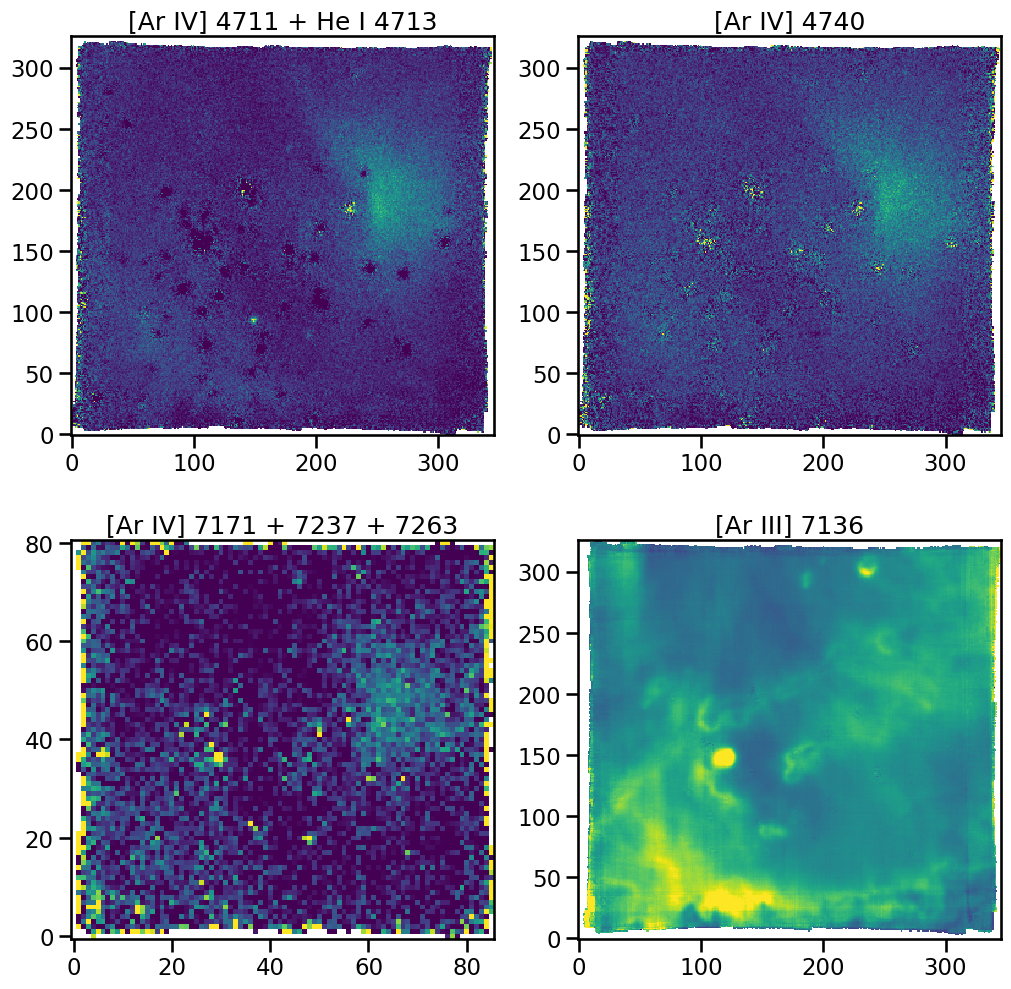

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
im4711.plot(ax=axes[0, 0], vmin=0, vmax=600)
im4740.plot(ax=axes[0, 1], vmin=0, vmax=450)
(im7171 + im7263 + im7237 - 0.3 * im8151).rebin(4).plot(ax=axes[1, 0], vmin=-3, vmax=30)
im7136.plot(ax=axes[1, 1], vmin=0, vmax=4500)
axes[0, 0].set_title("[Ar IV] 4711 + He I 4713")
axes[0, 1].set_title("[Ar IV] 4740")
axes[1, 0].set_title("[Ar IV] 7171 + 7237 + 7263")
axes[1, 1].set_title("[Ar III] 7136")

Text(0.5, 1.0, '[Ar III] 7136')

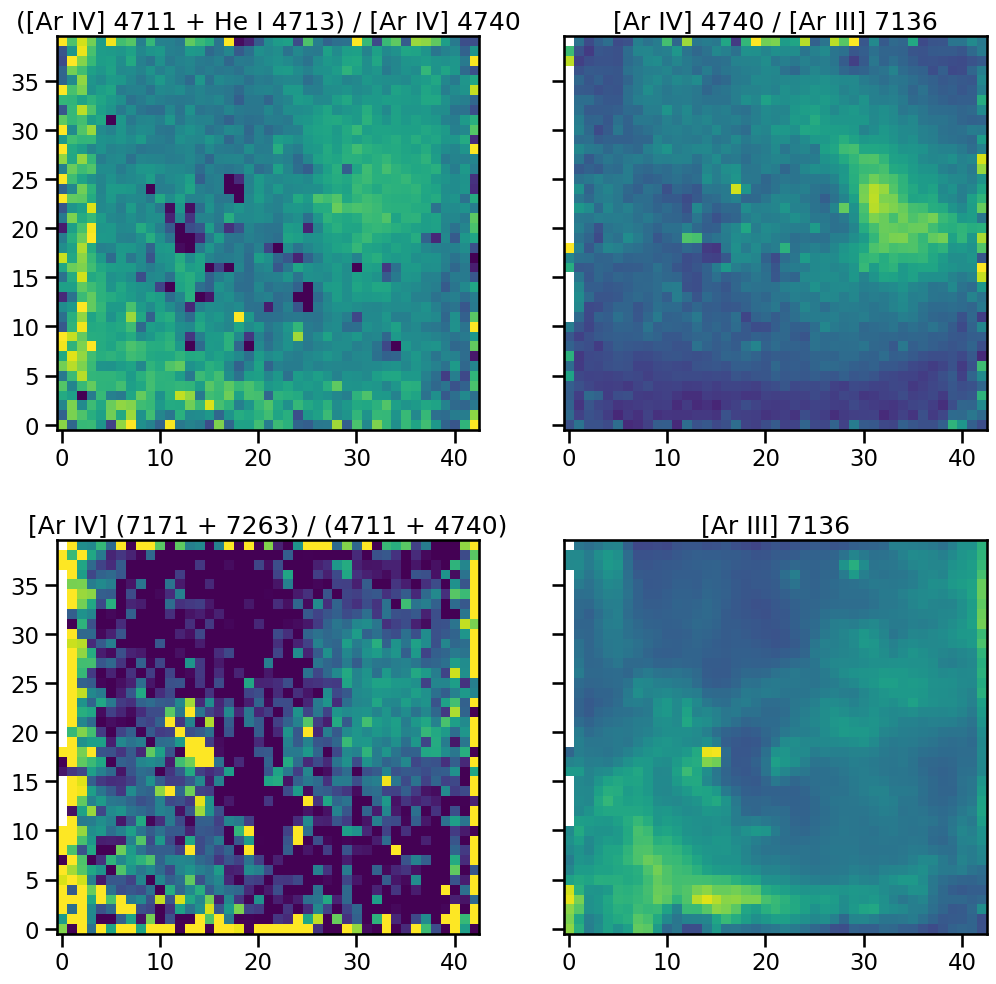

In [10]:
n = 8
fig, axes = plt.subplots(2, 2, sharey=True, figsize=(12, 12))
(im4711.rebin(n) / im4740.rebin(n)).plot(ax=axes[0, 0], vmin=0, vmax=2)
(im4740.rebin(n) / im7136.rebin(n)).plot(ax=axes[0, 1], vmin=0, vmax=0.1)
(
    (im7171 + im7263 + im7237 - 0.3 * im8151).rebin(n)
    / (im4740.rebin(n) + im4711.rebin(n))
).plot(ax=axes[1, 0], vmin=-0.02, vmax=0.06)
im7136.rebin(n).plot(ax=axes[1, 1], vmin=0, vmax=5500)
axes[0, 0].set_title("([Ar IV] 4711 + He I 4713) / [Ar IV] 4740")
axes[0, 1].set_title("[Ar IV] 4740 / [Ar III] 7136")
axes[1, 0].set_title("[Ar IV] (7171 + 7263) / (4711 + 4740)")
axes[1, 1].set_title("[Ar III] 7136")

### Now look at [Cl IV]

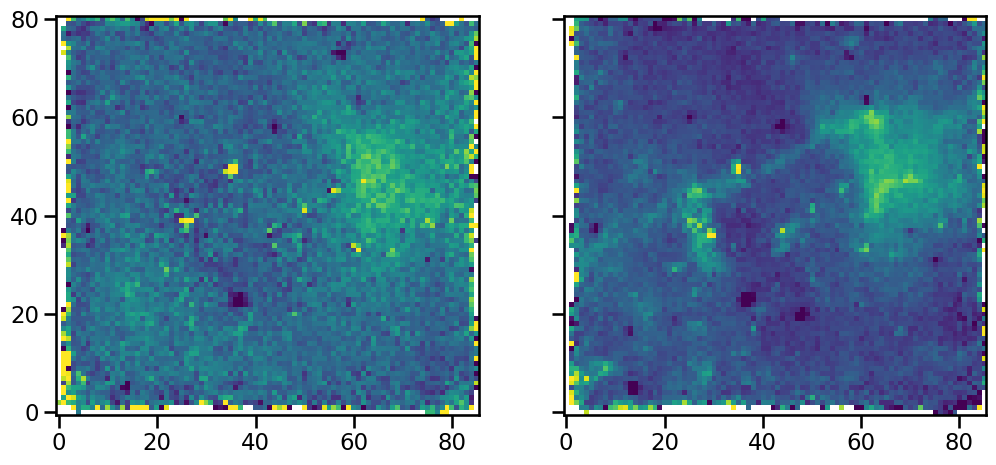

In [11]:
n = 4
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
im7530.rebin(n).plot(ax=axes[0], vmin=0, vmax=40)
im8046.rebin(n).plot(ax=axes[1], vmin=0, vmax=80)

Subtract the molecular H component

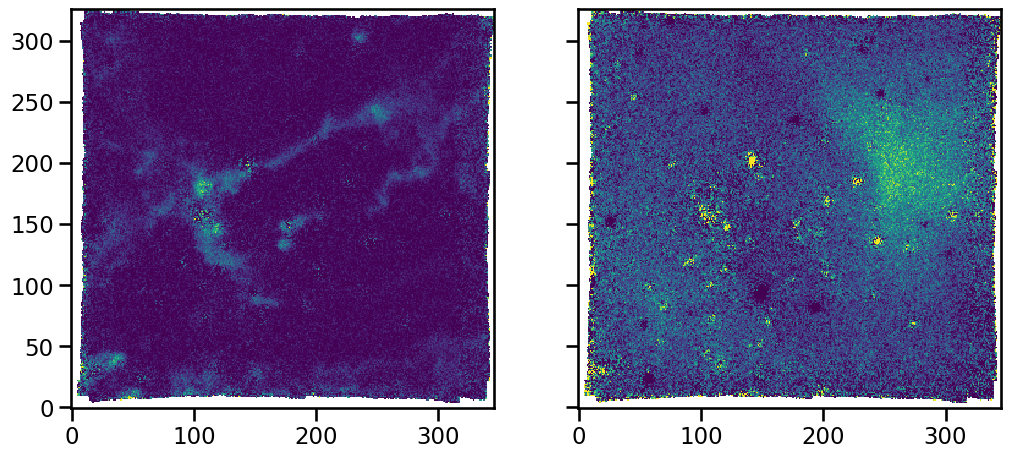

In [12]:
n = 1
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
im8151.rebin(n).plot(ax=axes[0], vmin=0, vmax=160)
(im8046 - 0.45 * im8151).rebin(n).plot(ax=axes[1], vmin=0, vmax=80)

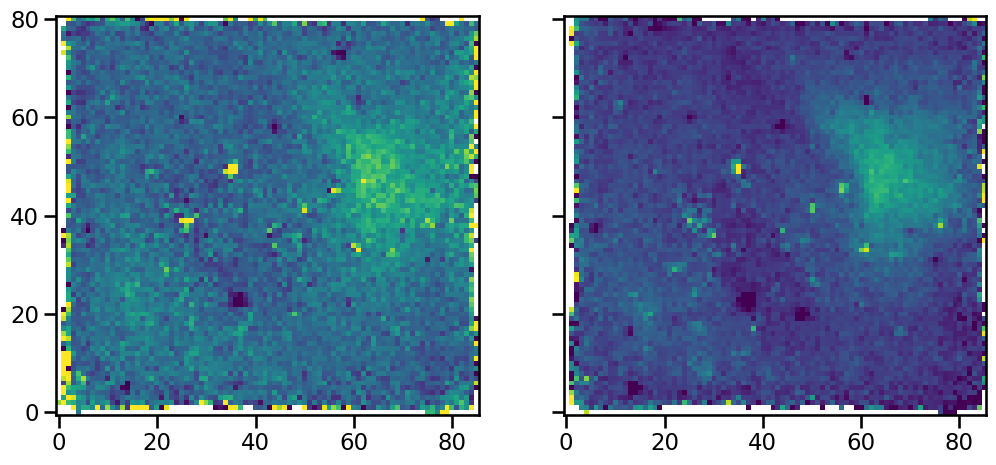

In [13]:
n = 4
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
im7530.rebin(n).plot(ax=axes[0], vmin=0, vmax=40)
(im8046 - 0.45 * im8151).rebin(n).plot(ax=axes[1], vmin=0, vmax=80)

### Finding an He I line to subtract

Now we must subtract the He I 4713 line from [Ar IV] 4711

In [14]:
hei = pn.RecAtom("He", 1)

In [15]:
dens = [10, 50, 100, 200, 400]
tems = [11000, 13000, 15000, 18000]
e4713 = hei.getEmissivity(tems, dens, wave=4713)
e5876 = hei.getEmissivity(tems, dens, wave=5876)
e6678 = hei.getEmissivity(tems, dens, wave=6678)
e7065 = hei.getEmissivity(tems, dens, wave=7065)
e7281 = hei.getEmissivity(tems, dens, wave=7281)
e4713 / e5876

array([[0.04018001, 0.04041871, 0.04052099, 0.04102455, 0.04151038],
       [0.04478989, 0.04505443, 0.04516687, 0.04574651, 0.04628835],
       [0.04927652, 0.04950486, 0.04960095, 0.05006681, 0.05048645],
       [0.05580846, 0.05582119, 0.05582645, 0.05571397, 0.05561849]])

There is a slight temperature dependence, but almost no density dependence if we use the 5876 line.  This is probably the best because it has good signal to noise.

We can assume that the He I temperature is the same as the [S III] temperature.

But we will check the other lines as well.

In [16]:
e4922 = hei.getEmissivity(tems, dens, wave=4922)
e5048 = hei.getEmissivity(tems, dens, wave=5048)
e4713 / e4922, e4713 / e5048, e4713 / e7065

(array([[0.40647141, 0.4093477 , 0.41058209, 0.4197778 , 0.42882288],
        [0.44643681, 0.45101333, 0.45297058, 0.46731489, 0.48121483],
        [0.48553439, 0.49177797, 0.4944359 , 0.51336974, 0.53137742],
        [0.5427877 , 0.55098623, 0.55444695, 0.57792091, 0.59955007]]),
 array([[2.6201732 , 2.62809804, 2.63147955, 2.66100576, 2.68942523],
        [2.65717403, 2.67070893, 2.67645533, 2.72186066, 2.76464152],
        [2.69116298, 2.71038632, 2.71850415, 2.77879408, 2.83442363],
        [2.73728489, 2.7644345 , 2.77581169, 2.85450951, 2.92517579]]),
 array([[0.22326467, 0.21858145, 0.21665065, 0.20348195, 0.19246447],
        [0.2265844 , 0.22037698, 0.21786125, 0.20165395, 0.18883985],
        [0.22955671, 0.22209605, 0.21911898, 0.2009038 , 0.18713682],
        [0.23350167, 0.22463296, 0.22116174, 0.20128646, 0.18696917]]))

The 4922 has the same T-dependence as 5876, just 10 times weaker. The 5048 has a constant ratio, but it is so weak that we cannot use it.  So 5876 it is ...

In [17]:
e6678 / e5876

array([[0.28397493, 0.2839017 , 0.28387033, 0.28362063, 0.28337974],
       [0.28326962, 0.28329251, 0.28330223, 0.28318797, 0.28308115],
       [0.28264415, 0.28286873, 0.28296323, 0.28322969, 0.28346971],
       [0.28181883, 0.28254556, 0.28284597, 0.28403077, 0.28503656]])

In [18]:
e7065 / e6678, e7281 / e7065

(array([[0.63373837, 0.65133009, 0.6588704 , 0.71085357, 0.76109242],
        [0.69783058, 0.72166589, 0.73179595, 0.80108095, 0.86589869],
        [0.75946891, 0.78799253, 0.7999816 , 0.87987912, 0.9517193 ],
        [0.84808621, 0.87950253, 0.892442  , 0.97450525, 1.043635  ]]),
 array([[0.3061047 , 0.30060112, 0.29833211, 0.28237236, 0.26901977],
        [0.30380156, 0.29629398, 0.29325134, 0.27322708, 0.25739514],
        [0.30168936, 0.29249668, 0.28882847, 0.26599959, 0.24874558],
        [0.29882711, 0.28769751, 0.28334138, 0.25807331, 0.23987128]]))

In [19]:
(e7065 + e7281) / e6678

array([[0.82772866, 0.84712064, 0.8554326 , 0.91157898, 0.96584133],
       [0.90983261, 0.93549115, 0.94639609, 1.01995796, 1.08877681],
       [0.9885926 , 1.01847772, 1.03103907, 1.1139266 , 1.18845527],
       [1.10151736, 1.13253321, 1.14530774, 1.22599905, 1.29397306]])

### Average values of T and reddening to use in the corrections

We would introduce too much noise by using the pixel-by-pixel values of $T$ and $E(B - V)$, so we will construct an average value by using the He I brightenss as a weight, but masking out the mYSO


In [20]:
def trim_edges(im, m):
    """Trim m pixels of each edge of image in place by setting mask"""
    im.mask[:m, :] = True
    im.mask[-m:, :] = True
    im.mask[:, :m] = True
    im.mask[:, -m:] = True
    return None

Get all the He and H lines that we might need

In [21]:
im5875 = get_image_raw("he-i-5875-62")
im4922 = get_image_raw("he-i-4921-93")
im5048 = get_image_raw("he-i-5047-74")
im5016 = get_image_raw("he-i-5015-68")
im6678 = get_image_raw("he-i-6678-15")
im7065 = get_image_raw("he-i-7065-28")
im7281 = get_image_raw("he-i-7281-35")

imhb = get_image_raw("h-i-4861-32")

im4686 = get_image_raw("he-ii-4685-68")

In [22]:
imEBV = Image(str(ROOT / "data/ngc346-ZZ-reddening-E_BV.fits"))

In [23]:
imT_siii = Image(str(ROOT / "data/ngc346-ZZ-T-siii.fits"))

Text(0.5, 1.0, 'Weight mask for He I emission')

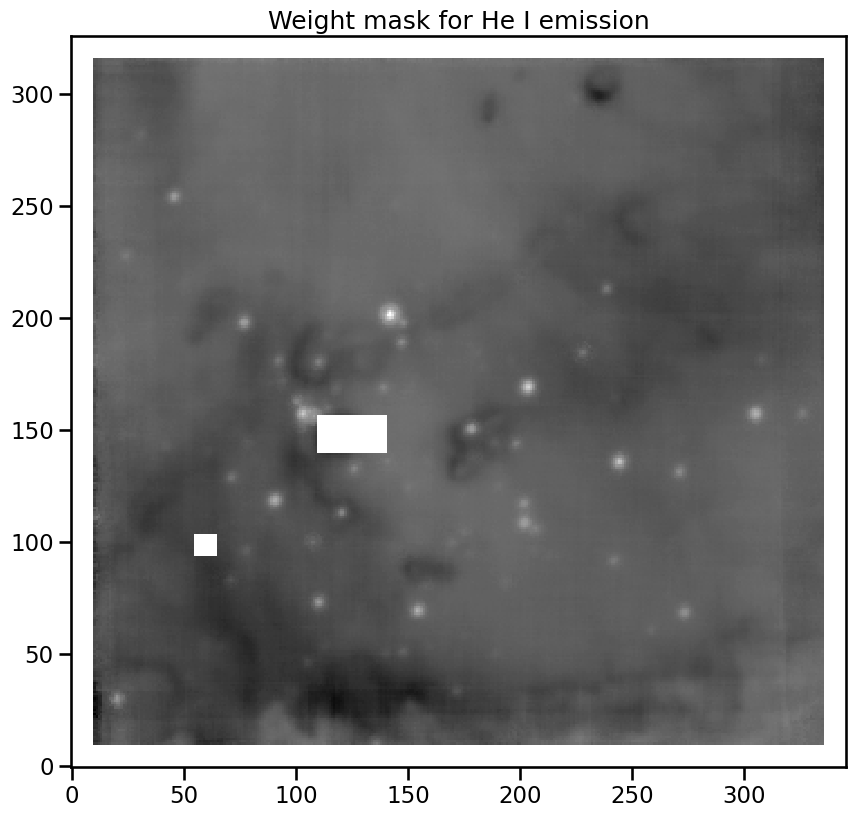

In [24]:
im_hei_weight = im5875.copy()
im_hei_weight.mask[140:157, 110:141] = True
im_hei_weight.mask[94:104, 55:65] = True
trim_edges(im_hei_weight, 10)
im_hei_weight.data.mask = im_hei_weight.mask
fig, ax = plt.subplots(figsize=(10, 10))
im_hei_weight.plot(cmap="gray_r")
ax.set_title("Weight mask for He I emission")

That looks OK. Now calculate some averages:

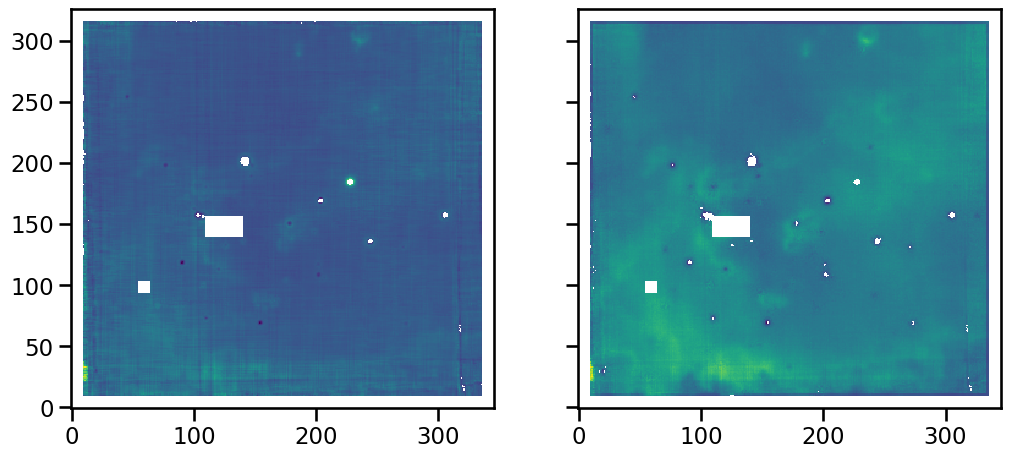

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
im1 = im_hei_weight.copy()
im1.data = im_hei_weight.data * imEBV.data
im1.mask = im_hei_weight.mask | imEBV.mask
im1.plot(ax=axes[0])
im2 = im_hei_weight.copy()
im2.data = im_hei_weight.data * imT_siii.data
im2.mask = im_hei_weight.mask | imT_siii.mask
im2.plot(ax=axes[1])

In [26]:
avHe_EBV = np.average(imEBV.data, weights=im_hei_weight.data)
avHe_Tsiii = np.average(imT_siii.data, weights=im_hei_weight.data)
f"He I brightness-weighted averages: E(B-V) = {avHe_EBV:.2f}, T = {avHe_Tsiii / 1000:.2f} kK"

'He I brightness-weighted averages: E(B-V) = 0.17, T = 13.09 kK'

In [27]:
median_EBV = np.nanmedian(imEBV[150:250, 200:300].data.data)
median_EBV

0.13737119734287262

The `avHe_Tsiii` looks good. But to be honest, I am a bit suspicious of the `avHe_EBV` reddening, since there are lots of anomalous spots of high $E(B-V)$ that correspond to stars (presumably underlying stellar absorption affecting the Balmer decrement).

I could use the median instead, but I have ended up using the weighted one after all, since we seem to be oversubtracting if anything.

In [28]:
avHe_reddening_4713_5876 = 10 ** (0.4 * avHe_EBV * (rc.X(4713) - rc.X(5876)))
median_reddening_4713_5876 = 10 ** (0.4 * median_EBV * (rc.X(4713) - rc.X(5876)))
avHe_reddening_4713_5876, median_reddening_4713_5876

(1.164439621239921, 1.134767289894211)

In [29]:
dens = 100.0
avHe_e4713_5876 = hei.getEmissivity(avHe_Tsiii, dens, wave=4713) / hei.getEmissivity(
    avHe_Tsiii, dens, wave=5876
)
avHe_e4713_5876

0.04537904691786201

Take advantage to save extinction-corrected maps of the high-ionization lines.  These are using the avHe reddening, not the pixel-by-pixel values

In [30]:
avHe_corr_4686 = 10 ** (0.4 * avHe_EBV * rc.X(4686))
avHe_corr_4686

1.6863131460517773

In [31]:
(im4686 * avHe_corr_4686).write(str(ROOT / "data/ngc346-ZZ-heii-4686-correct.fits"))

In [32]:
((imhb) * 10 ** (0.4 * avHe_EBV * rc.X(4861))).write(
    str(ROOT / "data/ngc346-ZZ-hi-4861-correct.fits"),
)
(im5875 * 10 ** (0.4 * avHe_EBV * rc.X(5875))).write(
    str(ROOT / "data/ngc346-ZZ-hei-5875-correct.fits"),
)
(im7136 * 10 ** (0.4 * avHe_EBV * rc.X(7136))).write(
    str(ROOT / "data/ngc346-ZZ-ariii-7136-correct.fits"),
)

### Subtract the contribution of He I 4713 to [Ar IV] 4711

Now do the correction by faking the 4713 line and subtracting it.

In [33]:
predicted_ratio_4713_5876 = avHe_e4713_5876 / avHe_reddening_4713_5876
predicted_ratio_4713_5876

0.03897071697847364

Although we have gone to all this trouble to calculate the "correct" intensity of the He I 4713 line, this is not much use, since we need to account for the fact that only a fraction of the He I line enters in the 3-wav pixels of [Ar IV].  This is the disadvantage of not summing over the entire line

We deal with this by taking the individual channels of the He I line, only using the A and B channels since for 4713 they overlap most with the [Ar IV] 4711 line

In [34]:
im5876_A = get_image_raw("he-i-5875-62", channel="A")
im5876_B = get_image_raw("he-i-5875-62", channel="B")

In [35]:
im_fake_4713 = predicted_ratio_4713_5876 * (im5876_A + 0.3 * im5876_B)
# im_fake_4713 = 0.025 * im5875
im4711c = im4711 - im_fake_4713

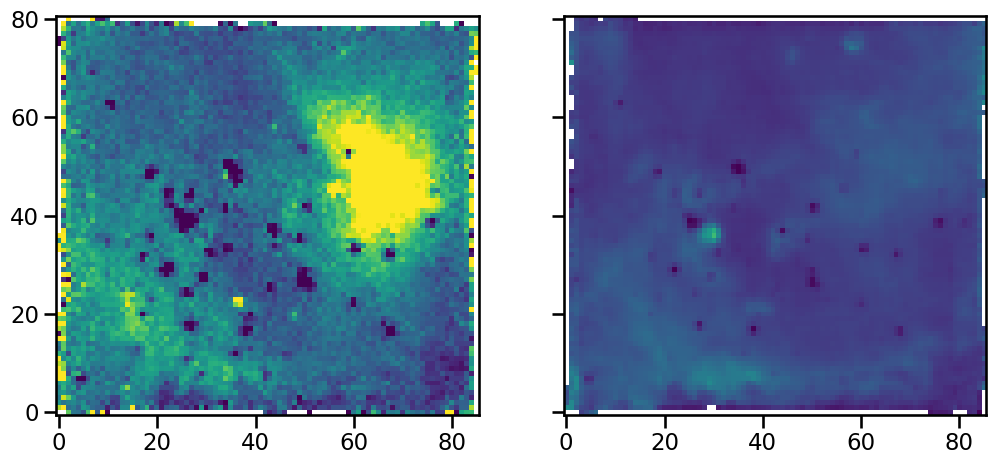

In [36]:
n = 4
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
im4711.rebin(n).plot(ax=axes[0], vmin=0, vmax=200)
(im_fake_4713).rebin(n).plot(ax=axes[1], vmin=0, vmax=200)

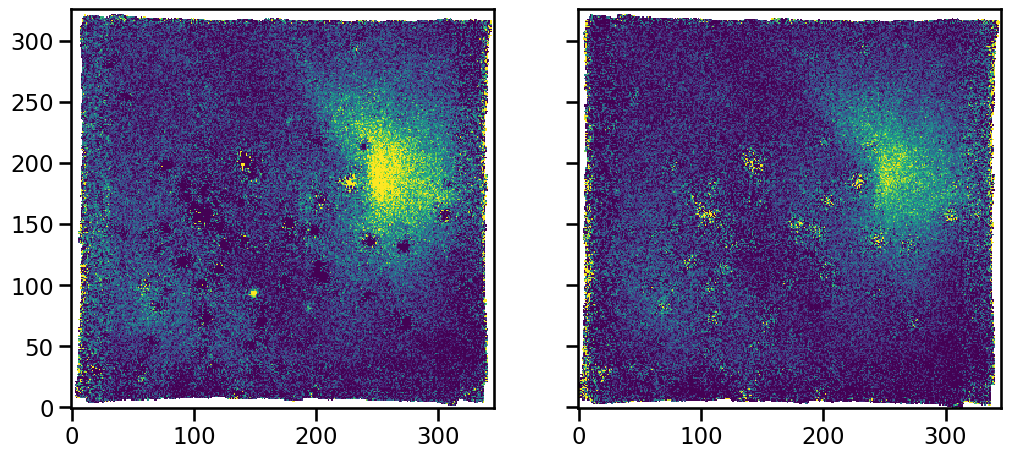

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
(im4711 - im_fake_4713).plot(ax=axes[0], vmin=0, vmax=250)
(im4740 - 50).plot(ax=axes[1], vmin=0, vmax=250)

Look at the joint distros

Text(0.5, 0.98, 'Correlation between [Ar IV] 4740, 4711 brightness')

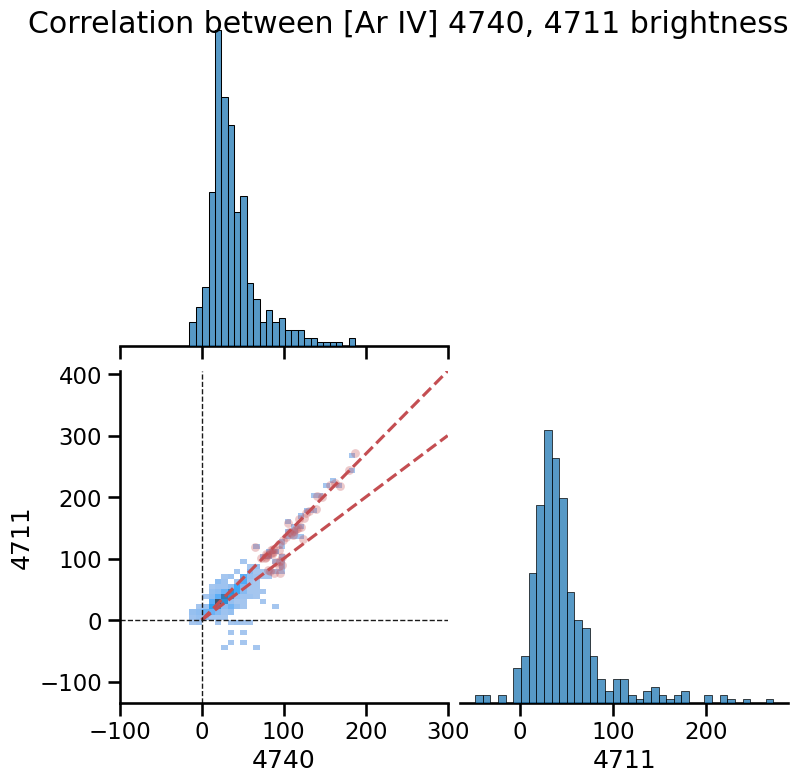

In [38]:
imax = 300
imin = -100
slope = 1.35
slope2 = 1.0
offset_4740 = 50
n = 16
x = (im4740 - offset_4740).rebin(n).data
y = (im4711 - im_fake_4713).rebin(n).data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > slope * imin)
m = m & ~im4740.rebin(n).mask & ~im4711.rebin(n).mask
df = pd.DataFrame(
    {
        "4740": x[m],
        "4711": y[m],
    }
)
mm = np.hypot(x, y / slope) > 100
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
g.axes[1, 0].plot([0, imax], [0, slope2 * imax], "--", c="r")
g.axes[1, 0].axhline(0, ls="dashed", color="k", lw=1)
g.axes[1, 0].axvline(0, ls="dashed", color="k", lw=1)
g.axes[1, 0].scatter(x[mm], y[mm], alpha=0.3, marker=".", s=10 * n, color="r", lw=0)
g.axes[1, 0].set(xlim=[imin, imax], ylim=[slope * imin, slope * imax])

g.fig.suptitle("Correlation between [Ar IV] 4740, 4711 brightness")

This shows that the we need to subtract an offset of around 50 from 4740 in order for it to be consistent with the He-subtracted 4711

Do the same for [Cl IV]


Text(0.5, 0.98, 'Correlation between [Cl IV] 8046, 7530 brightness')

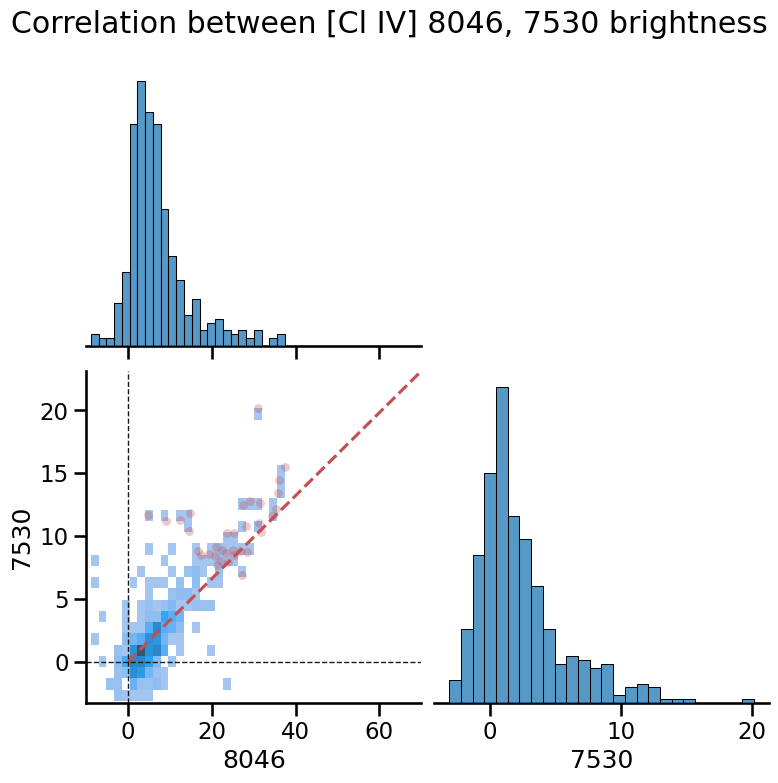

In [39]:
imax = 70
imin = -10
slope = 0.33
slope2 = 1.0
offset_4740 = 50
n = 16
x = (im8046 - 0.45 * im8151 - 12).rebin(n).data
y = (im7530 - 10 - 3).rebin(n).data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > slope * imin)
m = m & ~im8046.rebin(n).mask & ~im7530.rebin(n).mask
df = pd.DataFrame(
    {
        "8046": x[m],
        "7530": y[m],
    }
)
mm = np.hypot(x, y / slope) > 30
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
# g.axes[1, 0].plot([0, imax], [0, slope2 * imax], "--", c="r")
g.axes[1, 0].axhline(0, ls="dashed", color="k", lw=1)
g.axes[1, 0].axvline(0, ls="dashed", color="k", lw=1)
g.axes[1, 0].scatter(x[mm], y[mm], alpha=0.3, marker=".", s=10 * n, color="r", lw=0)
g.axes[1, 0].set(xlim=[imin, imax], ylim=[slope * imin, slope * imax])

g.fig.suptitle("Correlation between [Cl IV] 8046, 7530 brightness")

Text(0.5, 0.98, 'Correlation between [Ar IV] 4740 and [Cl IV] 8046 brightness')

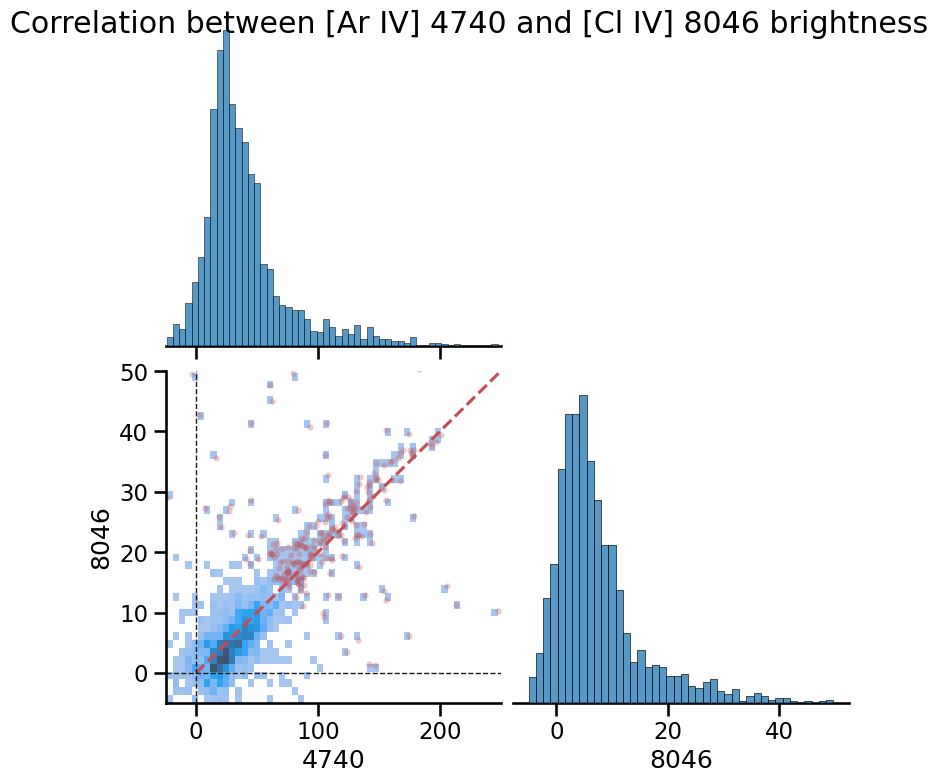

In [40]:
imax = 250
imin = -25
slope = 0.2
slope2 = 1.0
offset_4740 = 50
n = 8
x = (im4740 - offset_4740).rebin(n).data
y = (im8046 - 0.45 * im8151 - 12).rebin(n).data
m = x < imax
m = m & (x > imin)
m = m & (y < slope * imax)
m = m & (y > slope * imin)
m = m & ~im8046.rebin(n).mask & ~im7530.rebin(n).mask
df = pd.DataFrame(
    {
        "4740": x[m],
        "8046": y[m],
    }
)
mm = np.hypot(x, y / slope) > 100
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
)
g.axes[1, 0].plot([0, imax], [0, slope * imax], "--", color="r")
# g.axes[1, 0].plot([0, imax], [0, slope2 * imax], "--", c="r")
g.axes[1, 0].axhline(0, ls="dashed", color="k", lw=1)
g.axes[1, 0].axvline(0, ls="dashed", color="k", lw=1)
g.axes[1, 0].scatter(x[mm], y[mm], alpha=0.3, marker=".", s=10 * n, color="r", lw=0)
g.axes[1, 0].set(xlim=[imin, imax], ylim=[slope * imin, slope * imax])

g.fig.suptitle("Correlation between [Ar IV] 4740 and [Cl IV] 8046 brightness")

### Apply mask to [Ar IV] ratios

Make a common minimal mask to use for all the [Ar IV] lines, which we will then combine with a brightness-based mask for the weaker lines and ratios:

#### Use the existing IV mask for simplicity

In [41]:
zone_iv_mask_file = list(ROOT.glob("**/*IV-mask*.fits"))[0]
zone_iii_mask_file = list(ROOT.glob("**/*III-mask*.fits"))[0]
zone_iv_mask_file

PosixPath('/Users/will/Dropbox/muse-hii-regions/data/n346-lines/zone-IV-mask.fits')

In [42]:
from astropy.io import fits

In [43]:
zone_iv_mask = fits.open(zone_iv_mask_file)[0].data
zone_iii_mask = fits.open(zone_iii_mask_file)[0].data

In [44]:
broad_mask = ~(zone_iii_mask + zone_iv_mask).astype(bool)
narrow_mask = ~zone_iv_mask.astype(bool)

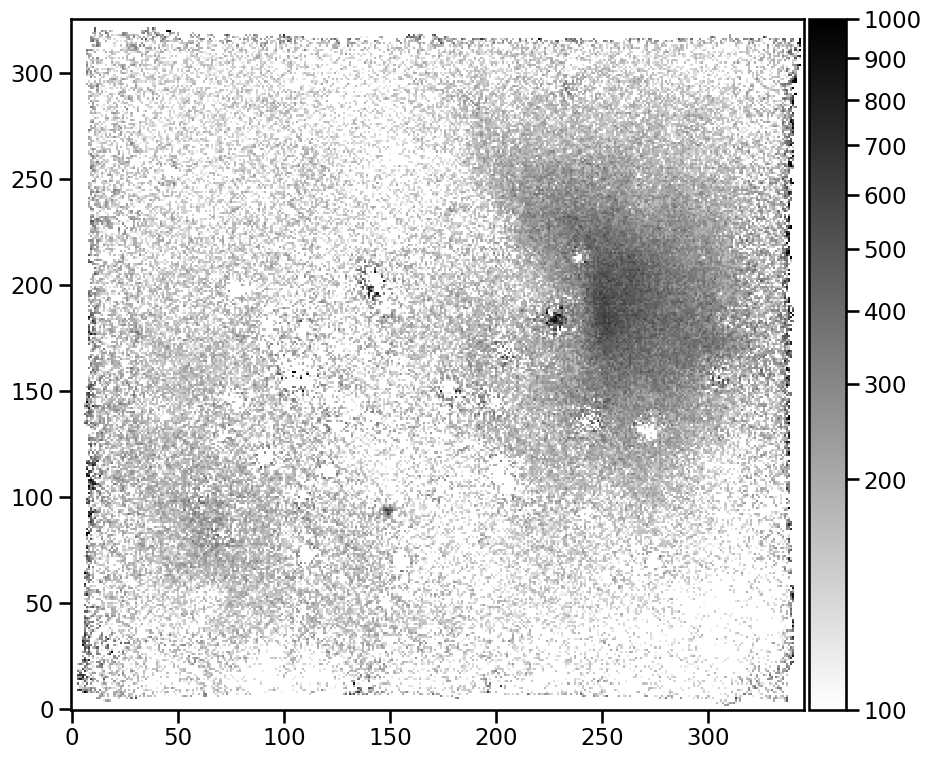

In [45]:
im_ariv_sum = im4711c + im4740
# im_ariv_sum.mask = broad_mask
fig, ax = plt.subplots(figsize=(10, 10))
im_ariv_sum.plot(colorbar="v", vmin=100, vmax=1000, cmap="gray_r", scale="sqrt")

Current strategy is not to apply these masks to the images, but to use them directly when I do the statistics

In [46]:
cont4861 = get_image_raw("h-i-4861-32", variant="cont")

That is looking good.

#### Apply the mask to all the other images

I am no longer doing this

In [47]:
# for im in im4711c, im4740, im7171, im7263, im7237:
#     im.mask = broad_mask

### Find average reddening for [Ar IV] lines

Now find average reddening for [Ar IV] lines.  Try two methods: (1) brightness-weighted mean; (2) make a mask based on the Ar IV brightness and then take median in that area.

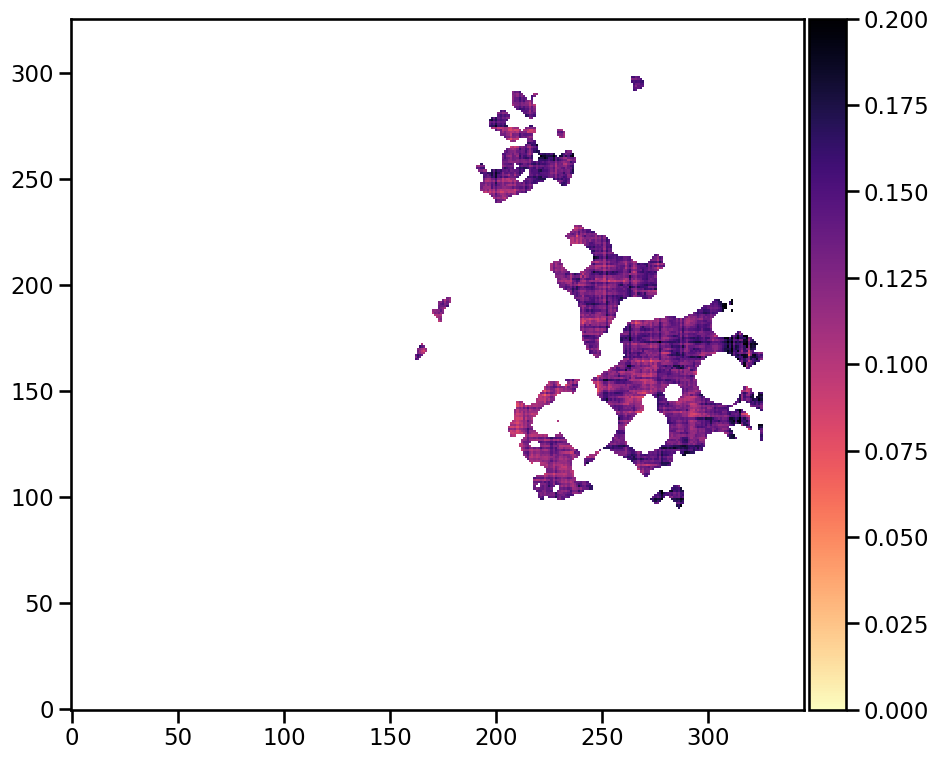

In [48]:
fig, ax = plt.subplots(figsize=(10, 10))
im = im_ariv_sum.copy()
im.data = np.where(
    narrow_mask,
    np.nan,
    imEBV.data,
)
# im.mask = im.mask | (im_ariv_sum.data < 300)
trim_edges(im, 20)
im.plot(vmin=0, vmax=0.2, cmap="magma_r", colorbar="v")

In [49]:
avArIV_EBV = np.average(
    imEBV.data[~narrow_mask], weights=im_ariv_sum.data[~narrow_mask]
)
medianArIV_EBV = np.nanmedian(im.data.data[~narrow_mask])
avArIV_EBV, medianArIV_EBV

(0.13389295881891972, 0.13421456515789032)

So there isn't much difference. But we take the median since it should be less sensitive to those spots of higher $E(B-V)$ due to stars.

### Apply extinction correction to all lines:

In [50]:
im7136r = (im7136) * 10 ** (0.4 * medianArIV_EBV * rc.X(7136))
im4740r = (im4740 - offset_4740) * 10 ** (0.4 * medianArIV_EBV * rc.X(4740))
im4711r = (im4711 - im_fake_4713) * 10 ** (0.4 * medianArIV_EBV * rc.X(4711))
im7171r = (im7171) * 10 ** (0.4 * medianArIV_EBV * rc.X(7171))
im7263r = (im7263) * 10 ** (0.4 * medianArIV_EBV * rc.X(7263))
im7237r = (im7237 - 0.3 * im8151) * 10 ** (0.4 * medianArIV_EBV * rc.X(7237))
for im in im4711r, im4740r, im7171r, im7136r, im7263r, im7237r:
    trim_edges(im, 20)

In [51]:
offsets = {
    "7171": 6,
    "7237": -11,
    "7263": -3,
}
offsets_sum = sum(offsets.values())
offsets_sum

-8

Note the offsets in the red lines, which I found from doing the correlation plots below. **But we do not apply these yet.**

And replace the summed image:

In [52]:
im_ariv_sum = im4711r + im4740r
im_ariv_red3 = im7171r + im7237r + im7263r

Calculate the ratios

In [53]:
ariv_R1 = im4711r / im4740r
# ariv_R1.mask = ariv_R1.mask | (im_ariv_sum.data < 400)
ariv_R345 = im_ariv_red3 / im_ariv_sum
# ariv_R345.mask = ariv_R345.mask | (im_ariv_sum.data < 400)

### Inspect maps of ariv lines

Text(0.5, 1.0, '[Ar IV] 7263')

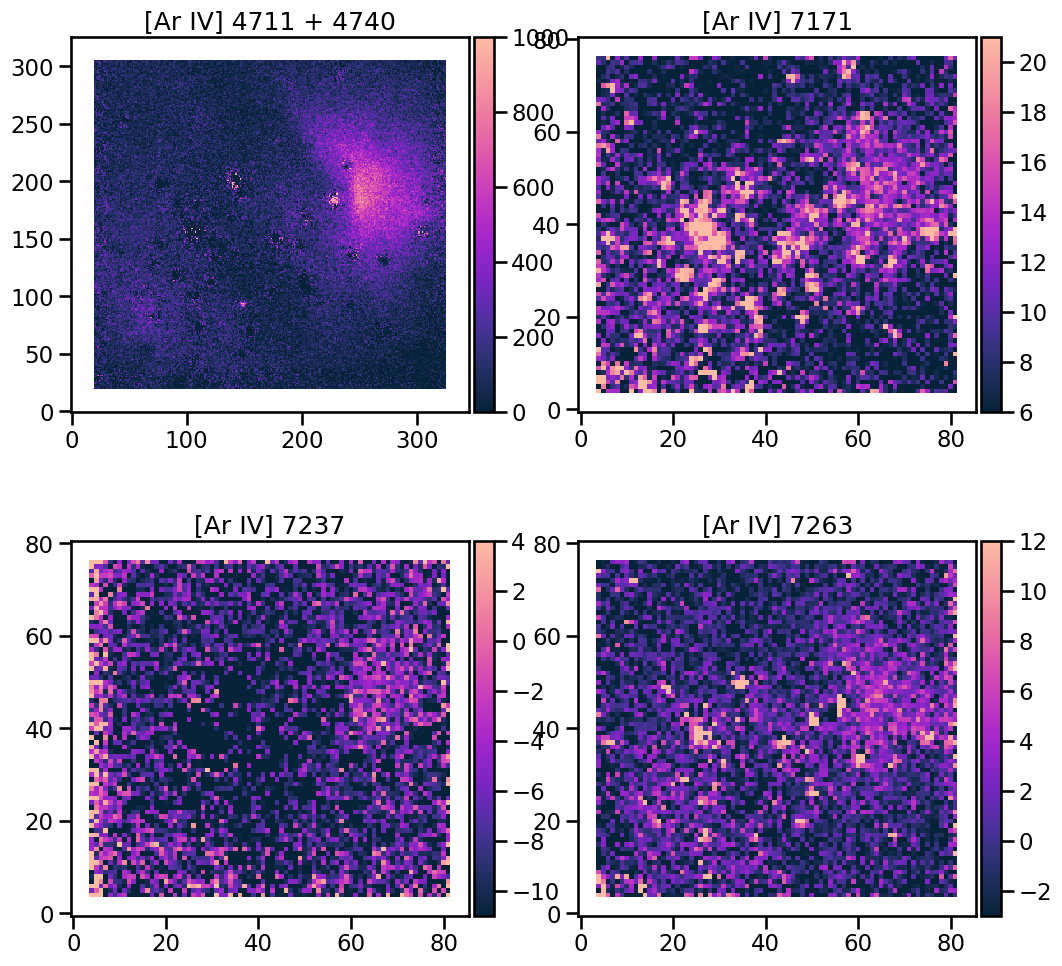

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
(im4711r + im4740r).plot(
    ax=axes[0, 0], vmin=0, vmax=1000, colorbar="v", cmap=cmr.bubblegum
)
n = 16
(im7171r).rebin(4).plot(
    ax=axes[0, 1],
    vmin=offsets["7171"],
    vmax=15 + offsets["7171"],
    colorbar="v",
    cmap=cmr.bubblegum,
)
(im7237r).rebin(4).plot(
    ax=axes[1, 0],
    vmin=offsets["7237"],
    vmax=15 + offsets["7237"],
    colorbar="v",
    cmap=cmr.bubblegum,
)
(im7263r).rebin(4).plot(
    ax=axes[1, 1],
    vmin=offsets["7263"],
    vmax=15 + offsets["7263"],
    colorbar="v",
    cmap=cmr.bubblegum,
)
axes[0, 0].set_title("[Ar IV] 4711 + 4740")
axes[0, 1].set_title("[Ar IV] 7171")
axes[1, 0].set_title("[Ar IV] 7237")
axes[1, 1].set_title("[Ar IV] 7263")

Text(0.5, 1.0, '[Ar IV] Sum 7XXX / Sum 47XX')

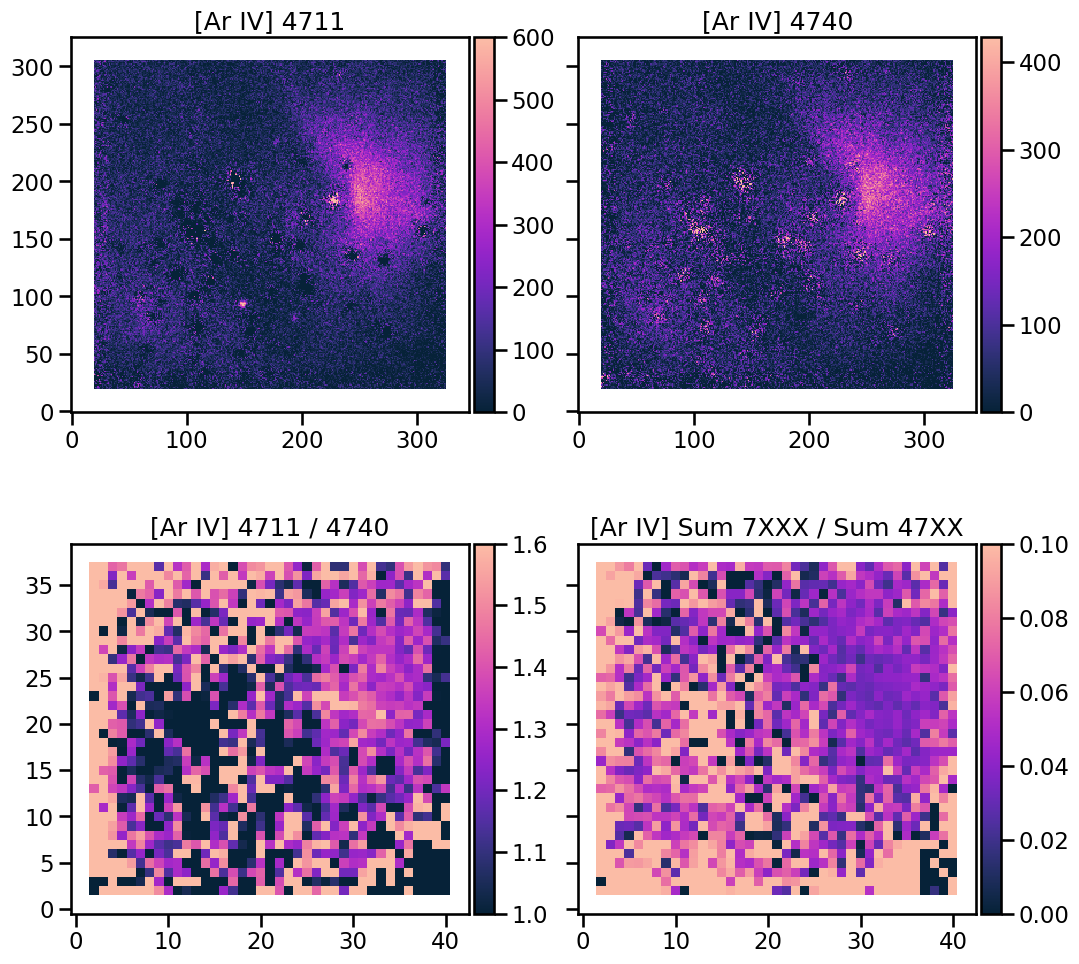

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex="row", sharey="row")
im4711r.plot(ax=axes[0, 0], vmin=0, vmax=600, colorbar="v", cmap=cmr.bubblegum)
im4740r.plot(ax=axes[0, 1], vmin=0, vmax=600 / 1.4, colorbar="v", cmap=cmr.bubblegum)
n = 8
(im4711r.rebin(n) / im4740r.rebin(n)).plot(
    ax=axes[1, 0], vmin=1.0, vmax=1.6, colorbar="v", cmap=cmr.bubblegum
)

((im_ariv_red3.rebin(n) - offsets_sum) / im_ariv_sum.rebin(n)).plot(
    ax=axes[1, 1], vmin=0, vmax=0.1, colorbar="v", cmap=cmr.bubblegum
)
axes[0, 0].set_title("[Ar IV] 4711")
axes[0, 1].set_title("[Ar IV] 4740")
axes[1, 0].set_title("[Ar IV] 4711 / 4740")
axes[1, 1].set_title("[Ar IV] Sum 7XXX / Sum 47XX")


Save the combined image, corrected for extinction:

In [56]:
im_ariv_sum.write(
    str(ROOT / "data/ngc346-ZZ-ariv-4711-plus-4740-correct.fits"), savemask="nan"
)
im_ariv_red3.write(
    str(ROOT / "data/ngc346-ZZ-ariv-7171-7237-7263-correct.fits"), savemask="nan"
)
im4740r.write(str(ROOT / "data/ngc346-ZZ-ariv-4740-correct.fits"), savemask="nan")
im4711r.write(str(ROOT / "data/ngc346-ZZ-ariv-4711-correct.fits"), savemask="nan")
im7171r.write(str(ROOT / "data/ngc346-ZZ-ariv-7171-correct.fits"), savemask="nan")
im7237r.write(str(ROOT / "data/ngc346-ZZ-ariv-7237-correct.fits"), savemask="nan")
im7263r.write(str(ROOT / "data/ngc346-ZZ-ariv-7263-correct.fits"), savemask="nan")
im7263r.write(str(ROOT / "data/ngc346-ZZ-ariv-7263-correct.fits"), savemask="nan")

### Density-sensitive correlations

Text(0.5, 0.98, 'Correlation between [Ar IV] 4711 and 4740')

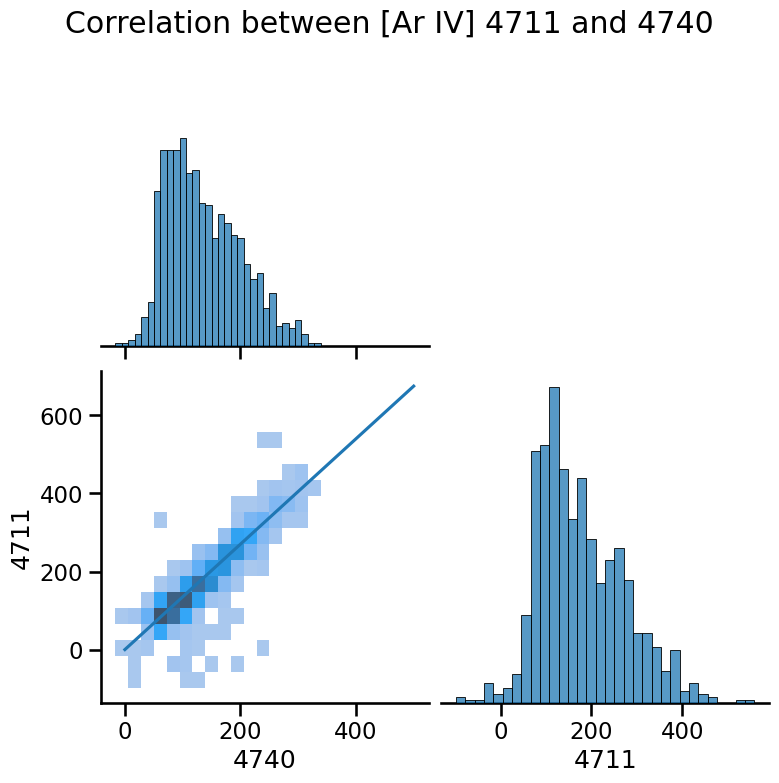

In [57]:
n = 4
xslice, yslice = slice(200, 300), slice(100, 250)
ratio = 1.35
xmax = 500
ymax = ratio * xmax
x = im4740r[yslice, xslice].rebin(n).data
y = im4711r[yslice, xslice].rebin(n).data
z = im_ariv_sum[yslice, xslice].rebin(n).data
m = (x > -100.0) & (y > -100.0) & (x < xmax) & (y < ymax)
# m = m & (x > 0)
# m = m & (y < 0.113)
# m = m & (y > 0.103)
m = m & ~im4740r[yslice, xslice].rebin(n).mask & ~im4711r[yslice, xslice].rebin(n).mask
df = pd.DataFrame(
    {
        "4740": x[m],
        "4711": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        # weights=z[m],
        bins=64 // n
    ),
    diag_kws=dict(
        # weights=z[m],
        bins=128 // n
    ),
)
g.axes[1, 0].plot([0, xmax], [0, ymax])
g.fig.suptitle("Correlation between [Ar IV] 4711 and 4740")

Text(0.5, 0.98, 'Correlation between [Ar IV] 4740 and 4711 / 4740')

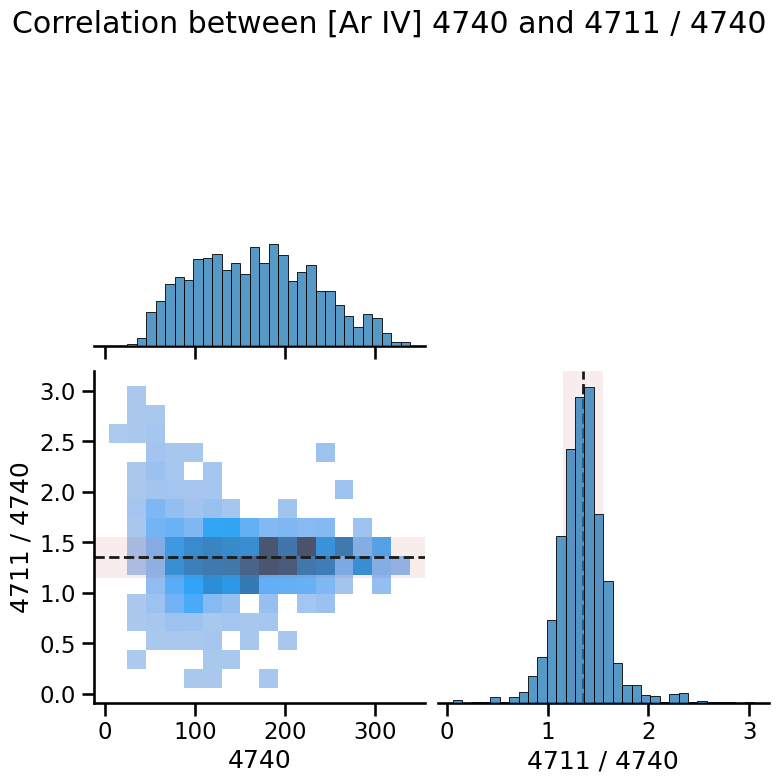

In [58]:
n = 4
xslice, yslice = slice(200, 300), slice(100, 250)
ratio = 1.35
dr = 0.2
rmin, rmax = ratio - dr, ratio + dr
xmax = 500
ymax = ratio * xmax
x = im4740r[yslice, xslice].rebin(n).data
y = im4711r[yslice, xslice].rebin(n).data
z = im_ariv_sum[yslice, xslice].rebin(n).data
m = (x > -100.0) & (y > -100.0) & (x < xmax) & (y < ymax)
y = y / x
m = m & (y < 2.5 * ratio) & (y > 0.0)
m = m & ~im4740[yslice, xslice].rebin(n).mask & ~im4711[yslice, xslice].rebin(n).mask
df = pd.DataFrame(
    {
        "4740": x[m],
        "4711 / 4740": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=64 // n),
    diag_kws=dict(weights=z[m], bins=128 // n),
)
g.axes[1, 0].axhline(ratio, linestyle="dashed", color="k", linewidth=2)
g.axes[1, 0].axhspan(rmin, rmax, color="r", linewidth=0, alpha=0.1)

g.axes[1, 1].axvline(ratio, linestyle="dashed", color="k", linewidth=2)
g.axes[1, 1].axvspan(rmin, rmax, color="r", linewidth=0, alpha=0.1)
g.fig.suptitle("Correlation between [Ar IV] 4740 and 4711 / 4740")

So the density-sensitive ratio is $R_1 = 1.35 \pm 0.2$

(array([   0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ,  629.40790816,  655.8628971 ,
        1246.13569683, 1333.43177105, 2619.13336954, 4083.12802636,
        3247.85289608, 6689.82316803, 4703.66583752, 2807.6299562 ,
        3232.0737153 ,    0.        ,  622.87128162,    0.        ,
           0.        ,    0.        ,    0.        ,    0.        ]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
        1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
        1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  ]),
 <BarContainer object of 40 artists>)

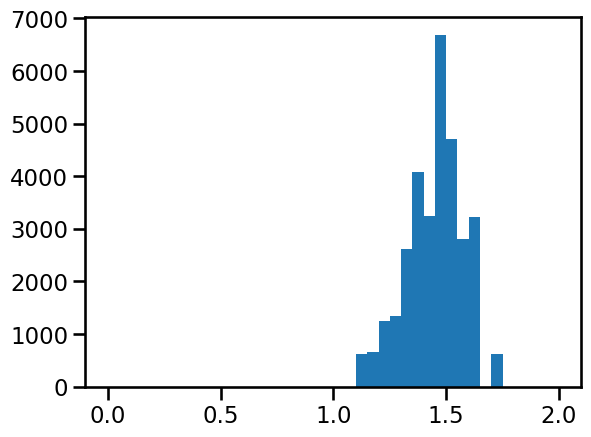

In [59]:
n = 4
fig, ax = plt.subplots()
m = im_ariv_sum.rebin(n).data > 600
ax.hist(
    ariv_R1.rebin(n).data[m],
    weights=im_ariv_sum.rebin(n).data[m],
    range=[0, 2.0],
    bins=40,
)

In [60]:
ariv = pn.Atom("Ar", 4)

In [61]:
ariv.getTemDen([1.1, 1.25, 1.35, 1.38], tem=17500, wave1=4711, wave2=4740)

array([2522.67611308,  970.33195304,  161.02620276,           nan])

In [62]:
ariv.getTemDen([1.1, 1.25, 1.35, 1.38], tem=15000, wave1=4711, wave2=4740)

array([2455.00789273, 1003.12041491,  233.67314247,   23.9502662 ])

So we are close to the low density limit, with a nominal value of 1000.  We need to get a very precise estimate of the uncertainty in order to get the error bars.

In [192]:
dens = [10, 50, 100, 200, 400]
tems = [10000, 15000, 20000]
ariv_lines = [4711, 4740, 7171, 7237, 7263]
e_ariv = {_wave: ariv.getEmissivity(tems, dens, wave=_wave) for _wave in ariv_lines}

In [64]:
e_ariv[4711] / e_ariv[4740]

array([[1.42166996, 1.41428758, 1.40517648, 1.38733359, 1.35309331],
       [1.38192688, 1.37602205, 1.36871811, 1.35436169, 1.32661513],
       [1.35361768, 1.34860075, 1.34238649, 1.33014406, 1.30637804]])

In [65]:
e_ariv[7171] / (e_ariv[4711] + e_ariv[4740])

array([[0.00801412, 0.00803107, 0.00805216, 0.00809406, 0.00817668],
       [0.01571663, 0.01574439, 0.01577897, 0.01584772, 0.0159836 ],
       [0.02197455, 0.0220092 , 0.02205238, 0.0221383 , 0.02230837]])

In [66]:
e_ariv[7263] / e_ariv[7171]

array([[0.85420557, 0.85389919, 0.85352024, 0.85277549, 0.85133662],
       [0.84589225, 0.84565703, 0.8453656 , 0.84479122, 0.84367535],
       [0.84327373, 0.84306527, 0.84280673, 0.84229632, 0.8413014 ]])

In [67]:
e_ariv[7237] / e_ariv[7171]

array([[0.74171871, 0.74171871, 0.74171871, 0.74171871, 0.74171871],
       [0.74171871, 0.74171871, 0.74171871, 0.74171871, 0.74171871],
       [0.74171871, 0.74171871, 0.74171871, 0.74171871, 0.74171871]])

In [68]:
ariv.getSources()

['Ar4: All A values (line gauge): Rynkun, P., Gaigalas, G., & Jonsson, P. 2019, Astronomy and Astrophysics, 623, A155: ',
 'Ar4: Energy levels: \n    Ref. 15349 of NIST 2014 (try this: http://physics.nist.gov/cgi-bin/ASBib1/get_ASBib_ref.cgi?db=el&db_id=15349&comment_code=&element=Ar&spectr_charge=4&): ',
 'Ar4: All collision strengths: Ramsbottom & Bell 1997, ADNDT, 66, 1: ']

In [193]:
def ariv_R1(T, d):
    top = ariv.getEmissivity(T, d, wave=4711)
    bottom = ariv.getEmissivity(T, d, wave=4740)
    return top / bottom

def ariv_R234(T, d):
    top = ariv.getEmissivity(T, d, wave=7171)
    top += ariv.getEmissivity(T, d, wave=7237)
    top += ariv.getEmissivity(T, d, wave=7263) 
    bottom = ariv.getEmissivity(T, d, wave=4711)
    bottom += ariv.getEmissivity(T, d, wave=4740)
    return top / bottom

In [194]:
ariv_R1(tems, dens)

array([[1.42166996, 1.41428758, 1.40517648, 1.38733359, 1.35309331],
       [1.38192688, 1.37602205, 1.36871811, 1.35436169, 1.32661513],
       [1.35361768, 1.34860075, 1.34238649, 1.33014406, 1.30637804]])

In [195]:
ariv_R234(tems, dens)

array([[0.02080404, 0.02084558, 0.02089729, 0.02099999, 0.02120259],
       [0.04066852, 0.04073666, 0.04082153, 0.04099028, 0.0413239 ],
       [0.05680404, 0.05688903, 0.05699495, 0.0572057 , 0.05762297]])

### Now for the T diagnostics

First, with all the lines

Text(0.5, 0.98, 'Correlation between [Ar IV] 4711+40 and 7171+')

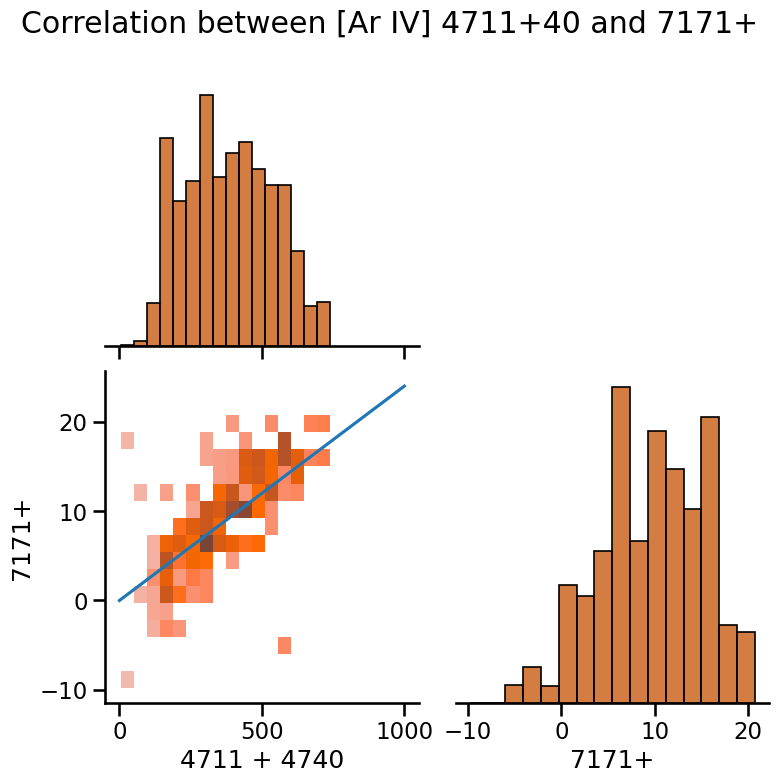

In [69]:
n = 8
color = "xkcd:dark orange"
xslice, yslice = slice(200, 300), slice(100, 250)
ratio = 0.024
xmin, xmax = -50, 1000
ymax = ratio * xmax
ymin = -0.5 * ymax
_im = im_ariv_sum.copy()
_im.data = np.where(
    # broad_mask,
    False,
    np.nan,
    _im.data,
)
x = im_ariv_sum[yslice, xslice].rebin(n).data
y = im_ariv_red3[yslice, xslice].rebin(n).data - (-3)
z = _im[yslice, xslice].rebin(n).data
m = (x > xmin) & (y > ymin) & (x < xmax) & (y < ymax)
m = (
    m
    & ~im_ariv_sum[yslice, xslice].rebin(n).mask
    & ~im_ariv_red3[yslice, xslice].rebin(n).mask
)
# m = m & (~broad_mask.rebin(n))
df = pd.DataFrame(
    {
        "4711 + 4740": x[m],
        "7171+": y[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=128 // n, color=color),
    diag_kws=dict(weights=z[m], bins=128 // n, color=color),
)
g.axes[1, 0].plot([0, xmax], [0, ymax])
g.fig.suptitle("Correlation between [Ar IV] 4711+40 and 7171+")

In [70]:
g.axes[1, 0].get_xlabel()

'4711 + 4740'

In [71]:
offsets

{'7171': 6, '7237': -11, '7263': -3}

#### Individual lines with narrow mask

7171 0.008014115599358234
7171 0.015716630175259542
7171 0.02197454619087335
7237 0.0059442194867692
7237 0.01165731866428329
7237 0.016298932060720382
7263 0.0068457022059966975
7263 0.013294575706129635
7263 0.018530557427629404


Text(0.5, 0.98, 'Correlation between [Ar IV] 4711+40 and each 7XXX line')

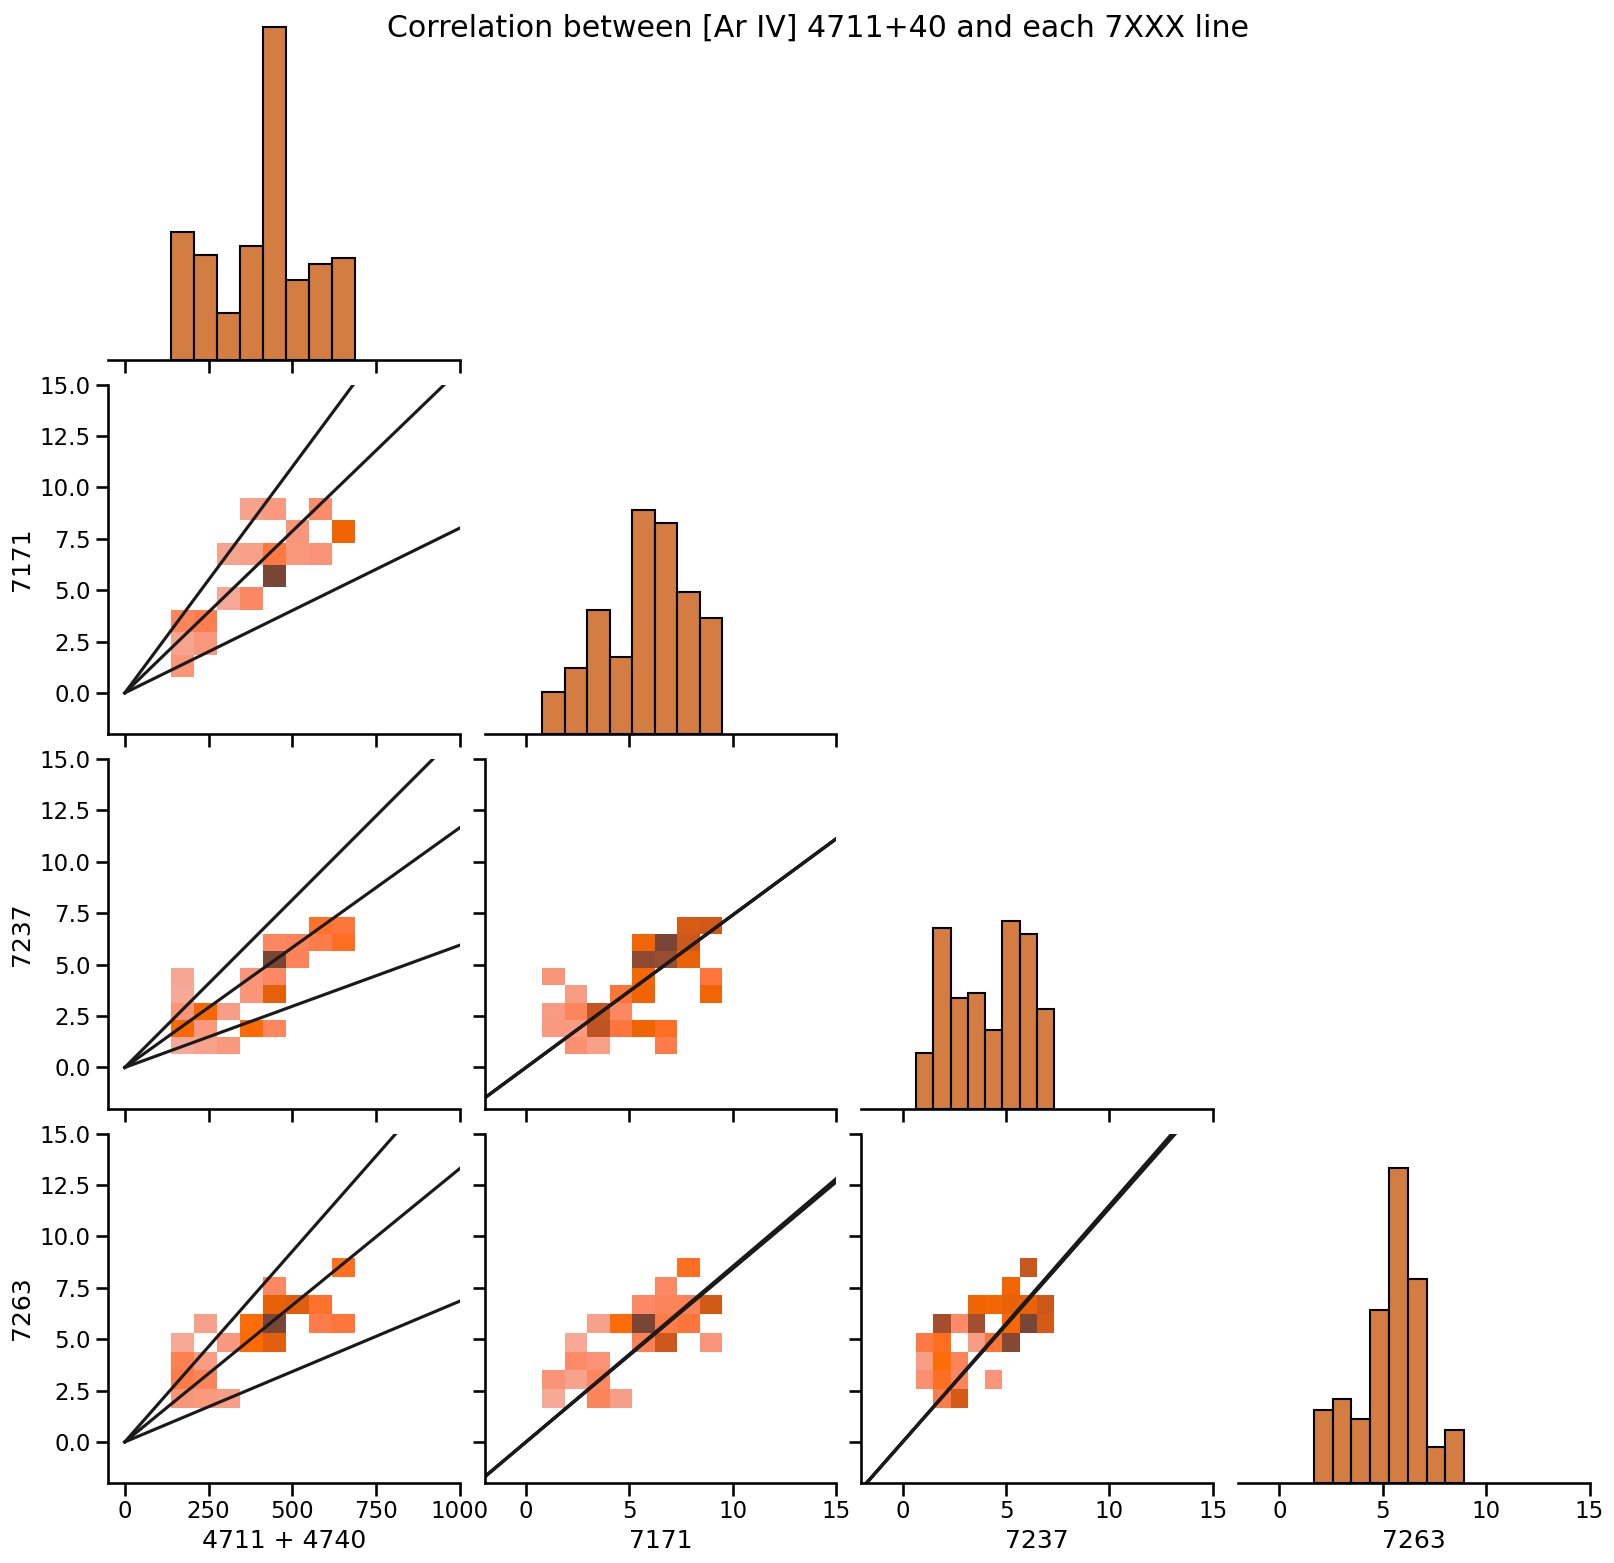

In [227]:
n = 16
color = "xkcd:dark orange"
xslice, yslice = slice(200, 300), slice(100, 250)
ratio = 0.016
xmin, xmax = -50, 1000
ymin, ymax = -2, 15
_im = im_ariv_sum.copy()
_im.data = np.where(
    narrow_mask,
    # False,
    np.nan,
    _im.data,
)
x = im_ariv_sum[yslice, xslice].rebin(n).data
# Ratio names from Keenan 1997
y4 = (im7171r[yslice, xslice] - offsets["7171"]).rebin(n).data
y2 = (im7237r[yslice, xslice] - offsets["7237"]).rebin(n).data
y3 = (im7263r[yslice, xslice] - offsets["7263"]).rebin(n).data
z = _im[yslice, xslice].rebin(n).data
m = (x > xmin) & (x < xmax)
m &= (y2 > ymin) & (y2 < ymax)
m &= (y3 > ymin) & (y3 < ymax)
m &= (y4 > ymin) & (y4 < ymax)
m = m & ~im_ariv_sum[yslice, xslice].rebin(n).mask
# m = m & (~broad_mask.rebin(n))
df = pd.DataFrame(
    {
        "4711 + 4740": x[m],
        "7171": y4[m],
        "7237": y2[m],
        "7263": y3[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=128 // n, color=color),
    diag_kws=dict(weights=z[m], bins=128 // n, color=color),
)
# g.axes[1, 0].plot([0, xmax], [0, ymax])
for ax in g.axes.flat:
    if ax:
        if "47" in ax.get_xlabel():
            ax.set_xlim(xmin, xmax)
            _line = ax.get_ylabel()
            try:
                _line = int(_line.strip())
                _ratios = e_ariv[_line] / (e_ariv[4711] + e_ariv[4740])
                for ratio in _ratios[:, 0]:
                    print(_line, ratio)
                    ax.plot([0, xmax], [0, ratio * xmax], color="k")
            except KeyError:
                pass
        else:
            ax.set_xlim(ymin, ymax)
            _xline = ax.get_xlabel()
            _yline = ax.get_ylabel()
            if _xline and _yline:
                _xline = int(_xline.strip())
                _yline = int(_yline.strip())
                _ratios = e_ariv[_yline] / e_ariv[_xline]
                for ratio in _ratios[:, 0]:
                    ax.plot([ymin, ymax], [ratio * ymin, ratio * ymax], color="k")

        if "47" in ax.get_ylabel():
            ax.set_ylim(xmin, xmax)
        else:
            ax.set_ylim(ymin, ymax)
g.fig.suptitle("Correlation between [Ar IV] 4711+40 and each 7XXX line")

In [228]:
df.describe()

,4711 + 4740,7171,7237,7263
count,47.000000,47.000000,47.000000,47.000000
mean,334.729517,4.998816,3.483332,4.641150
std,145.583590,2.312437,1.989197,1.545289
min,137.431166,0.781605,-1.191837,1.667899
25%,194.572658,3.325500,1.973058,3.315446
50%,335.710766,5.145268,3.216716,4.794007
75%,448.396298,6.574306,5.089850,5.444218
max,688.456567,9.477209,7.330670,8.946891


In [229]:
df.corr()

,4711 + 4740,7171,7237,7263
4711 + 4740,1.000000,0.815322,0.723509,0.824970
7171,0.815322,1.000000,0.481924,0.742082
7237,0.723509,0.481924,1.000000,0.499319
7263,0.824970,0.742082,0.499319,1.000000


#### Individual temperature estimates

We use the mean values from the dataframe, assigning a fraction $(1 - r^2)$ of the total variance to the variance in the ratio, where $r$ is the correlation coefficient. 

**Note that these do not have the weighting applied** But that is OK, since we decided to go with the unweighted stats in the next section on joint T-n stats too. The justification is the errors are mainly systematic.

First 7171

In [230]:
sig = 2.3 * np.sqrt(1 - 0.81532**2)
T_7171 = ariv.getTemDen(
    (4.99 + np.array([-sig, 0.0, sig])) / 334.7, 
    den=200, 
    to_eval="L(7171) / (L(4711) + L(4740))"
)
T_7171 = np.round(T_7171 / 1000, 1)
T_7171

array([11.8, 14.4, 17.3])

Next 7237

In [231]:
sig = 1.989 * np.sqrt(1 - 0.724**2)
T_7237 = ariv.getTemDen(
    (3.48 + np.array([-sig, 0.0, sig])) / 334.7, 
    den=200, 
    to_eval="L(7237) / (L(4711) + L(4740))",
)
T_7237 = np.round(T_7237 / 1000, 1)
T_7237

array([10.2, 13.8, 17.8])

Finally 7263

In [233]:
sig = 1.545 * np.sqrt(1 - 0.825**2)
T_7263 = ariv.getTemDen(
    (4.64 + np.array([-sig, 0.0, sig])) / 334.7, 
    den=200, 
    to_eval="L(7263) / (L(4711) + L(4740))",
)
T_7263 = np.round(T_7263 / 1000, 1)
T_7263

array([13.3, 15.4, 17.8])

#### Individual lines with no mask

7171 0.008014115599358234
7171 0.015716630175259542
7171 0.02197454619087335
7237 0.0059442194867692
7237 0.01165731866428329
7237 0.016298932060720382
7263 0.0068457022059966975
7263 0.013294575706129635
7263 0.018530557427629404


Text(0.5, 0.98, 'Correlation between [Ar IV] 4711+40 and each 7XXX line')

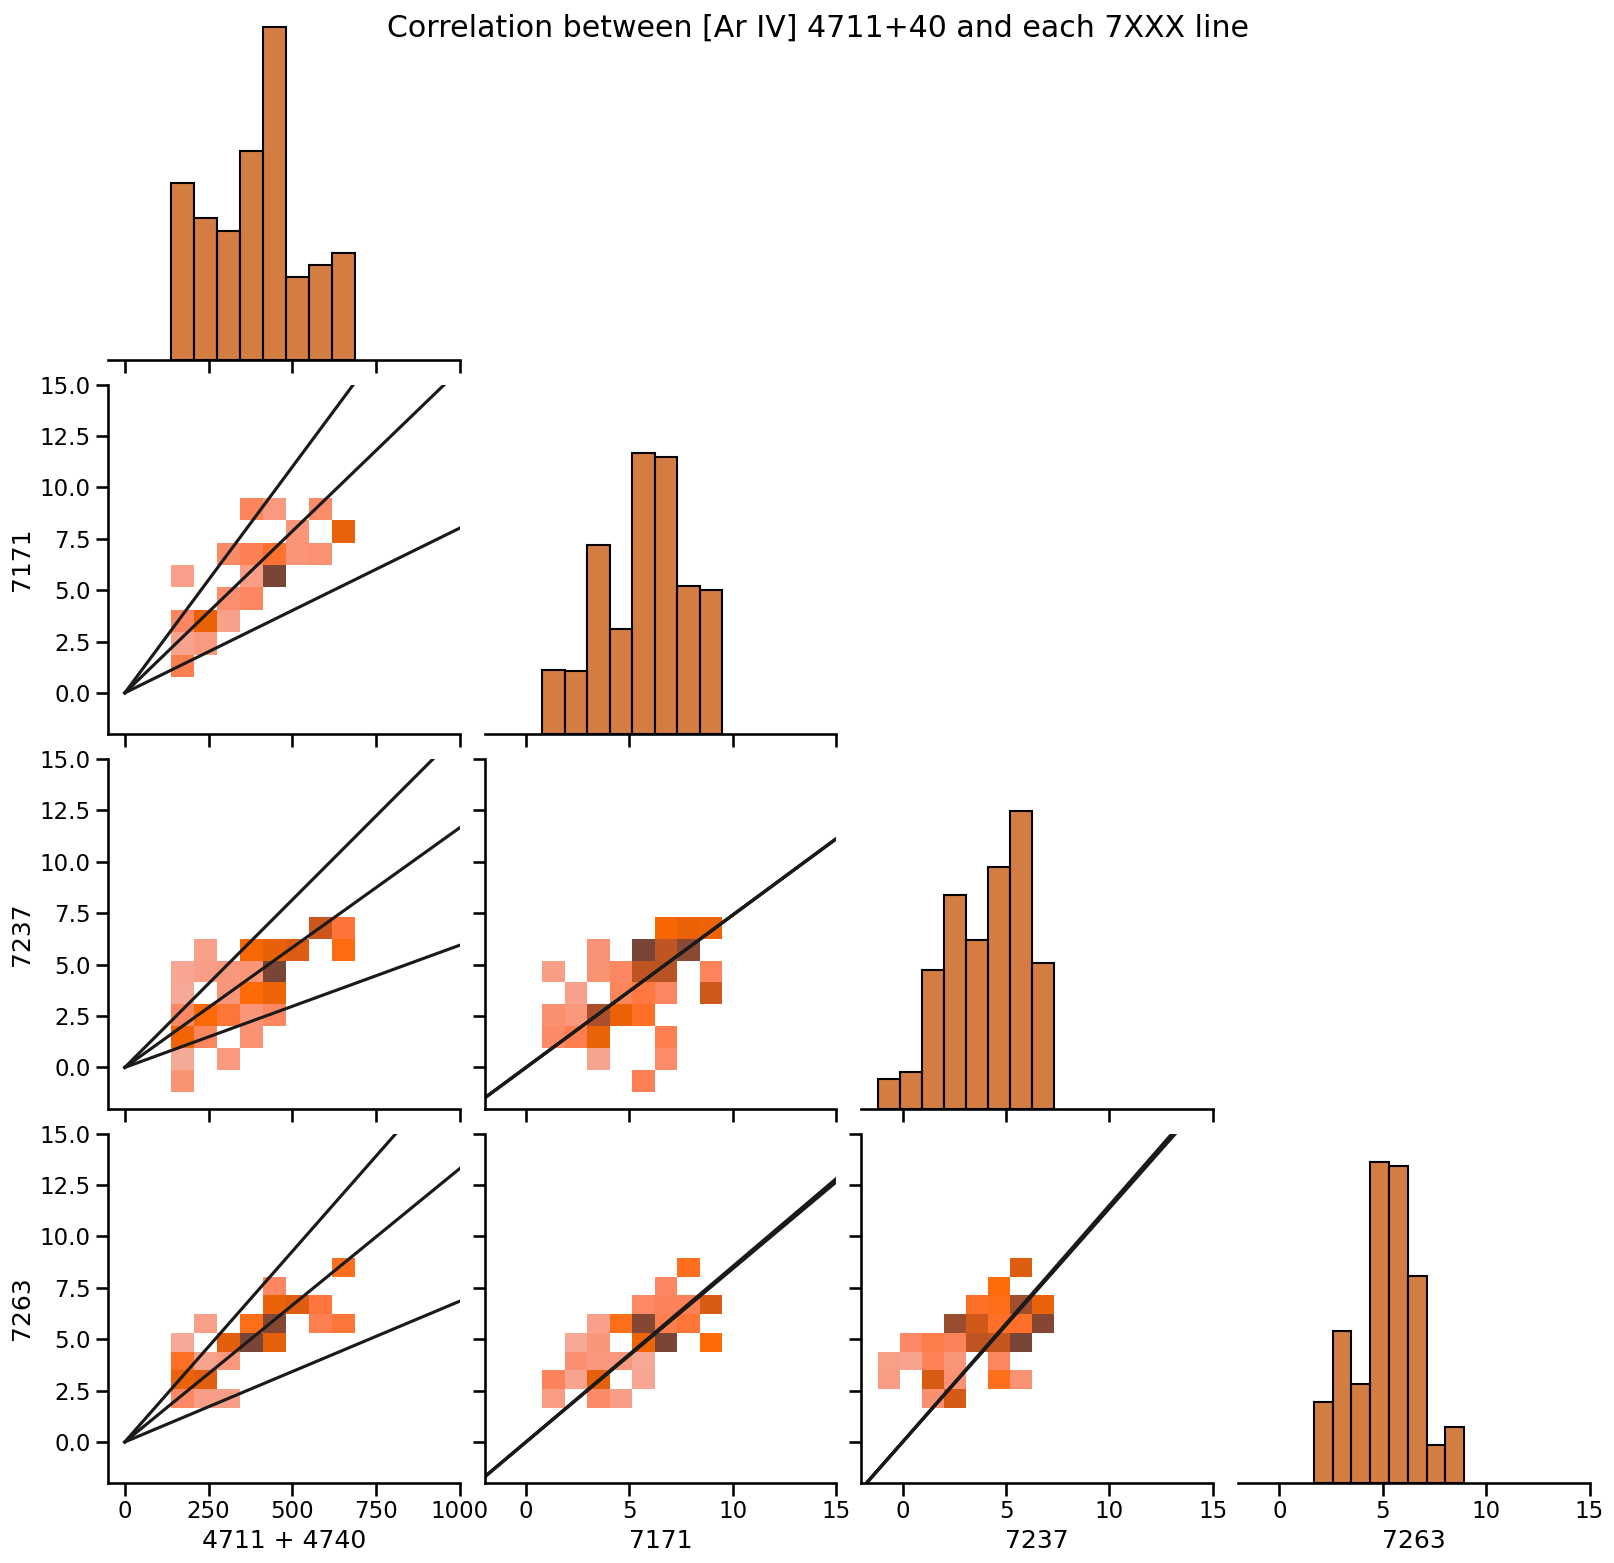

In [224]:
n = 16
color = "xkcd:dark orange"
xslice, yslice = slice(200, 300), slice(100, 250)
ratio = 0.016
xmin, xmax = -50, 1000
ymin, ymax = -2, 15
_im = im_ariv_sum.copy()
_im.data = np.where(
    # narrow_mask,
    False,
    np.nan,
    _im.data,
)
x = im_ariv_sum[yslice, xslice].rebin(n).data
# Ratio names from Keenan 1997
y4 = (im7171r[yslice, xslice] - offsets["7171"]).rebin(n).data
y2 = (im7237r[yslice, xslice] - offsets["7237"]).rebin(n).data
y3 = (im7263r[yslice, xslice] - offsets["7263"]).rebin(n).data
z = _im[yslice, xslice].rebin(n).data
m = (x > xmin) & (x < xmax)
m &= (y2 > ymin) & (y2 < ymax)
m &= (y3 > ymin) & (y3 < ymax)
m &= (y4 > ymin) & (y4 < ymax)
m = m & ~im_ariv_sum[yslice, xslice].rebin(n).mask
# m = m & (~broad_mask.rebin(n))
df = pd.DataFrame(
    {
        "4711 + 4740": x[m],
        "7171": y4[m],
        "7237": y2[m],
        "7263": y3[m],
    }
)
g = sns.pairplot(
    df,
    kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(weights=z[m], bins=128 // n, color=color),
    diag_kws=dict(weights=z[m], bins=128 // n, color=color),
)
# g.axes[1, 0].plot([0, xmax], [0, ymax])
for ax in g.axes.flat:
    if ax:
        if "47" in ax.get_xlabel():
            ax.set_xlim(xmin, xmax)
            _line = ax.get_ylabel()
            try:
                _line = int(_line.strip())
                _ratios = e_ariv[_line] / (e_ariv[4711] + e_ariv[4740])
                for ratio in _ratios[:, 0]:
                    print(_line, ratio)
                    ax.plot([0, xmax], [0, ratio * xmax], color="k")
            except KeyError:
                pass
        else:
            ax.set_xlim(ymin, ymax)
            _xline = ax.get_xlabel()
            _yline = ax.get_ylabel()
            if _xline and _yline:
                _xline = int(_xline.strip())
                _yline = int(_yline.strip())
                _ratios = e_ariv[_yline] / e_ariv[_xline]
                for ratio in _ratios[:, 0]:
                    ax.plot([ymin, ymax], [ratio * ymin, ratio * ymax], color="k")

        if "47" in ax.get_ylabel():
            ax.set_ylim(xmin, xmax)
        else:
            ax.set_ylim(ymin, ymax)
g.fig.suptitle("Correlation between [Ar IV] 4711+40 and each 7XXX line")

### Now make the joint density-temperature plot

In [74]:
im7171rr = im7171r - offsets["7171"]
im7237rr = im7237r - offsets["7237"]
im7263rr = im7263r - offsets["7263"]
im7xxx = im7171rr + im7237rr + im7263rr

These are all fine.  Now include density and temperature indicators together:



In [75]:
Ts = [5e3, 1e4, 1.5e4, 2.0e4, 2.5e4, 3.0e4]
# dens = [10.0, 100.0, 1000.0]
dens = [1.0, 200.0, 400.0, 600.0, 800.0, 1000.0]


Tfine = np.linspace(Ts[0], Ts[-1], 500)
dfine = np.linspace(dens[0], dens[-1], 500)

e4711 = ariv.getEmissivity(Tfine, dens, wave=4711)
e4740 = ariv.getEmissivity(Tfine, dens, wave=4740)
e7171 = ariv.getEmissivity(Tfine, dens, wave=7171)
e7237 = ariv.getEmissivity(Tfine, dens, wave=7237)
e7263 = ariv.getEmissivity(Tfine, dens, wave=7263)

rr1 = e4711 / e4740
rr4 = e7263 / (e4711 + e4740)
rr2 = e7171 / (e4711 + e4740)
rr3 = e7237 / (e4711 + e4740)
rr234 = rr2 + rr3 + rr4

e4711 = ariv.getEmissivity(Ts, dfine, wave=4711)
e4740 = ariv.getEmissivity(Ts, dfine, wave=4740)
e7171 = ariv.getEmissivity(Ts, dfine, wave=7171)
e7237 = ariv.getEmissivity(Ts, dfine, wave=7237)
e7263 = ariv.getEmissivity(Ts, dfine, wave=7263)

_rr1 = e4711 / e4740
_rr4 = e7263 / (e4711 + e4740)
_rr2 = e7171 / (e4711 + e4740)
_rr3 = e7237 / (e4711 + e4740)

_rr1 = _rr1.T
_rr2 = _rr2.T
_rr3 = _rr3.T
_rr4 = _rr4.T
_rr234 = _rr2 + _rr3 + _rr4


Following function is copied from the matplotlib docs.  Ideas originally from https://carstenschelp.github.io/2018/09/14/Plot_Confidence_Ellipse_001.html

I have modified it to include a weight array.


In [76]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# See: https://carstenschelp.github.io/2018/09/14/Plot_Confidence_Ellipse_001.html


def confidence_ellipse(x, y, w, ax, n_std=3.0, facecolor="none", **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    w : array-like, shape (n, )
        Weights of each input point.

    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y, aweights=w)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensionl dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse(
        (0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor=facecolor,
        **kwargs,
    )

    # Calculating the stdandard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.average(x, weights=w)

    # calculating the stdandard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.average(y, weights=w)

    transf = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)
    )

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

'R1 = 1.349 +/- 0.078, R2 + R3 + R4 = 0.038 +/- 0.004'

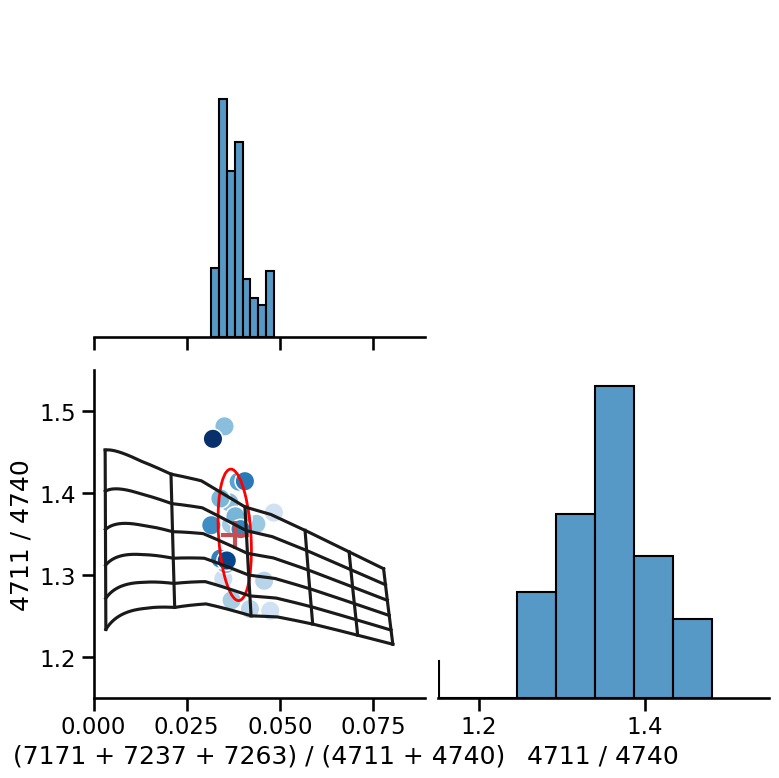

In [108]:
n = 16
xslice, yslice = slice(230, 300), slice(144, 245)
w_low_cutoff = 250
w_mid_cutoff = 300  # 375
xymin, xymax = 0.00, 0.089
zzmin, zzmax = 1.15, 1.55

_im = im_ariv_sum.copy()
_im.data = np.where(
    # narrow_mask,
    False,
    np.nan,
    _im.data,
)

w = _im[yslice, xslice].rebin(n).data
x = im7xxx[yslice, xslice].rebin(n).data / w
z = im4711r[yslice, xslice].rebin(n).data / im4740r[yslice, xslice].rebin(n).data
m = w > w_mid_cutoff  # & (w < wmax)
# m = m & (x + y > 0.25*ratio) & (x + y < 2*ratio)
m = m & (z > 1.1) & (z < 2.1)
# m = m & ~ariv_R1[yslice, xslice].rebin(n).mask & ~ariv_R3_plus_R4[yslice, xslice].rebin(n).mask
df = pd.DataFrame(
    {
        "(7171 + 7237 + 7263) / (4711 + 4740)": x[m],
        "4711 / 4740": z[m],
        "sum": w[m],
    }
).sort_values(by="sum")
mean_R1 = np.average(z[m], weights=w[m])
mean_R234 = np.average(x[m], weights=w[m])

var_R1 = np.average((z[m] - mean_R1) ** 2, weights=w[m])
var_R234 = np.average((x[m] - mean_R234) ** 2, weights=w[m])

sig_R1 = np.sqrt(var_R1)
sig_R234 = np.sqrt(var_R234)

text = f"R1 = {mean_R1:.3f} +/- {sig_R1:.3f}"
text += f", R2 + R3 + R4 = {mean_R234:.3f} +/- {sig_R234:.3f}"

_vars = df.columns[:2]
g = sns.pairplot(
    df,
    x_vars=_vars,
    y_vars=_vars,
    kind="scatter",
    diag_kind="hist",
    height=4,
    corner=True,
    plot_kws=dict(
        c=df["sum"],
        cmap="Blues",
        s=200,
        vmin=w_low_cutoff,
    ),
    diag_kws=dict(
        weights=w[m],
        bins=8,
        #    bins=128//n,
    ),
)
g.axes[1, 0].plot(rr234, rr1, color="k")
g.axes[1, 0].plot(_rr234, _rr1, color="k")
confidence_ellipse(
    x[m],
    z[m],
    w[m],
    g.axes[1, 0],
    n_std=1,
    edgecolor="red",
    linewidth=2,
)
g.axes[1, 0].scatter(
    mean_R234,
    mean_R1,
    c="r",
    marker="+",
    s=400,
    linewidth=3,
)

g.axes[1, 0].set_xlim(xymin, xymax)
g.axes[1, 0].set_ylim(zzmin, zzmax)

g.axes[1, 1].set_xlim(*g.axes[1, 0].get_ylim())
g.axes[0, 0].set_xlim(*g.axes[1, 0].get_xlim())

g.fig.savefig(ROOT / "figs/ngc346-ZZ-bow-shock-ariv-diagnostics-R1-R3.pdf")
# g.fig.suptitle("Correlation between [Ar IV] ratios");
text

In [107]:
df.columns

Index(['(7171 + 7237 + 7263) / (4711 + 4740)', '4711 / 4740', 'sum'], dtype='object')

### Single-panel version for the paper

R1 = 1.367 +/- 0.059, R2 + R3 + R4 = 0.037 +/- 0.004
Number of big pixels: 18, each with 256 original pixels


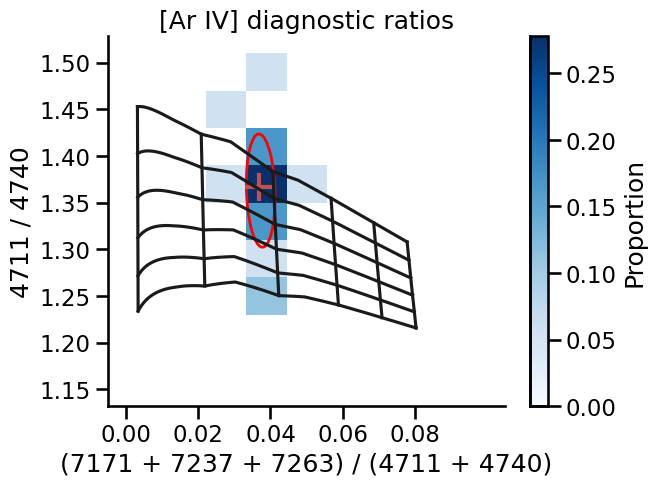

In [184]:
n = 16
xslice, yslice = slice(230, 300), slice(144, 245)

xmin, xmax = 0, 0.1
ymin, ymax = 1.15, 1.51

_im = im_ariv_sum.copy()
_im.data = np.where(
    # narrow_mask,
    # broad_mask,
    False,
    np.nan,
    _im.data,
)

w = _im[yslice, xslice].rebin(n).data
x = im7xxx[yslice, xslice].rebin(n).data / w
y = im4711r[yslice, xslice].rebin(n).data / im4740r[yslice, xslice].rebin(n).data
# m = w > w_mid_cutoff  #
m = m & (x > xmin) & (x < xmax)
m = m & (y > ymin) & (y < ymax)

df = pd.DataFrame(
    {
        "(7171 + 7237 + 7263) / (4711 + 4740)": x[m],
        "4711 / 4740": y[m],
        "sum": w[m],
    }
).sort_values(by="sum")

mean_R1 = np.average(y[m], weights=w[m])
mean_R234 = np.average(x[m], weights=w[m])

var_R1 = np.average((y[m] - mean_R1) ** 2, weights=w[m])
var_R234 = np.average((x[m] - mean_R234) ** 2, weights=w[m])

sig_R1 = np.sqrt(var_R1)
sig_R234 = np.sqrt(var_R234)

text = f"R1 = {mean_R1:.3f} +/- {sig_R1:.3f}"
text += f", R2 + R3 + R4 = {mean_R234:.3f} +/- {sig_R234:.3f}"

text += f"\nNumber of big pixels: {np.sum(m)}"
text += f", each with {n**2} original pixels"

g = sns.histplot(
    df,
    x=df.columns[0],
    y=df.columns[1],
    bins=9,
    binrange=[[xmin, xmax], [ymin, ymax]],
    # weights="sum",
    cbar=True,
    cbar_kws=dict(label="Proportion"),
    stat="proportion",
    cmap="Blues",
    # thresh=0.15,
)
g.plot(rr234, rr1, color="k")
g.plot(_rr234, _rr1, color="k")
confidence_ellipse(
    x[m],
    y[m],
    np.ones_like(w[m]), 
    # w[m],
    g,
    n_std=1,
    edgecolor="red",
    linewidth=2,
)
g.scatter(
    mean_R234,
    mean_R1,
    c="r",
    marker="+",
    s=400,
    linewidth=3,
)
g.set_xticks(0.02 * np.arange(5))
g.set_title("[Ar IV] diagnostic ratios")
sns.despine()
plt.gcf().savefig(
    ROOT / "figs/ngc346-ZZ-bow-shock-ariv-diagnostics-R1-R234.pdf",
    bbox_inches="tight",
)
print(text)

In [186]:
5/18

0.2777777777777778

#### Calculate the limits on density and temperature

In [239]:
T_R234 = ariv.getTemDen(
    (mean_R234 + np.array([-sig_R234, 0.0, sig_R234])), 
    den=180, 
    to_eval="(L(7171) + L(7237) + L(7263)) / (L(4711) + L(4740))",
)
T_R234 = np.round(T_R234 / 1000, 1)
T_R234

array([13. , 13.9, 14.9])

In [235]:
T_7171, T_7237, T_7263

(array([11.8, 14.4, 17.3]),
 array([10.2, 13.8, 17.8]),
 array([13.3, 15.4, 17.8]))

In [242]:
den_R1 = ariv.getTemDen(
    (mean_R1 + np.array([-sig_R1, 0.0, sig_R1])), 
    tem=13900,
    to_eval="L(4711) / L(4740)",
)
den_R1

array([597.94551089, 187.70850366,          nan])

So we get $T = 13.9 \pm 1.0$ kK and $n = 190^{+400}_{-190}$ pcc

In [79]:
n = 8
xslice, yslice = slice(230, 300), slice(144, 245)
w_low_cutoff = 250
w_mid_cutoff = 350  # 375
xymin, xymax = 0.011, 0.059
zzmin, zzmax = 1.11, 1.5

ww = im_ariv_sum[yslice, xslice].rebin(n)
xx = im7263r[yslice, xslice].rebin(n) / ww
yy = im7171r[yslice, xslice].rebin(n) / ww

In [80]:
(xx.mask).sum()

0

In [81]:
xx.mask?

Type:        property
String form: <property object at 0x150bf58f0>
Docstring:  
The shared masking array of the data and variance arrays.

This is a bool array which has the same shape as the data and variance
arrays. Setting an element of this array to True, flags the
corresponding pixels of the data and variance arrays, so that they
don't take part in subsequent calculations. Reverting this element to
False, unmasks the pixel again.

This array can be modified either directly by assignments to elements
of this property or by modifying the masks of the .data and .var
arrays. An entirely new mask array can also be assigned to this
property, provided that it has the same shape as the data array.

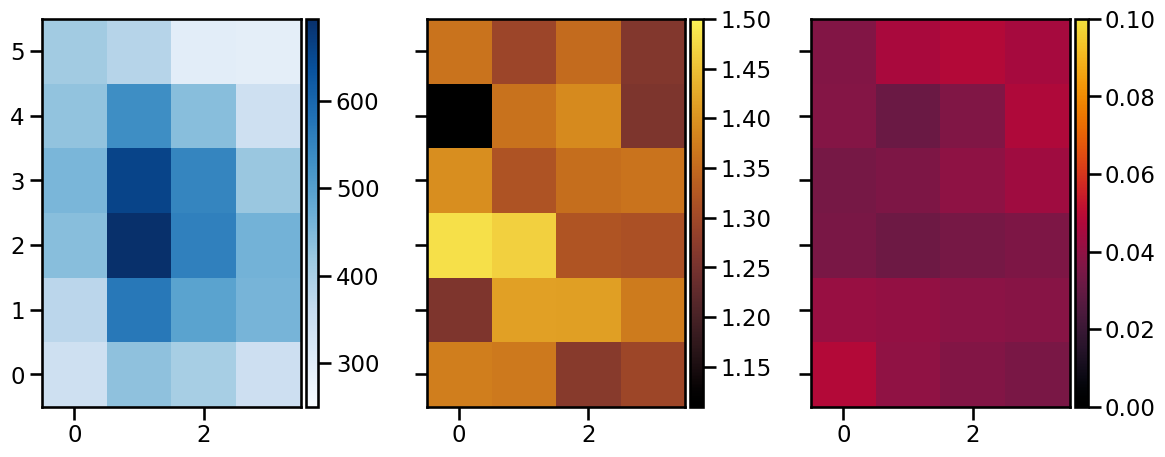

In [191]:
n = 16
xslice, yslice = slice(230, 300), slice(144, 245)
w_low_cutoff = 250
w_mid_cutoff = 350  # 375
xxmin, xxmax = 0.0, 0.1
zzmin, zzmax = 1.11, 1.5

ww = im_ariv_sum[yslice, xslice].rebin(n)
xx = im7xxx[yslice, xslice].rebin(n) / ww
zz = im4711r[yslice, xslice].rebin(n) / im4740r[yslice, xslice].rebin(n)
mm = ww.data > w_low_cutoff  # & (ww.data < wmax)
# mm = mm & (xy.data > xymin) & (xy.data < xymax)
# mm = mm & (zz.data > zzmin) & (zz.data < zzmax)
ww.mask = ww.mask #| ~mm | (ww.data < w_mid_cutoff)
xx.mask = ww.mask
zz.mask = ww.mask
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(12, 5))
ww.plot(ax=axes[0], colorbar="v", vmin=w_low_cutoff, vmax=None, cmap="Blues")
zz.plot(ax=axes[1], colorbar="v", vmin=zzmin, vmax=zzmax, cmap=cmr.amber)
xx.plot(ax=axes[2], colorbar="v", vmin=xxmin, vmax=xxmax, cmap=cmr.ember)
fig.tight_layout()
fig.savefig(ROOT / "figs/ngc346-PZ-bow-shock-ariv-diagnostics-maps.pdf")